# **REDES NEURONALES ARTIFICIALES**





# **0. Preparación**

## **0.1. Librerías**

In [ ]:
import pandas as pd
import gdown
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import matplotlib.cm as cm
from matplotlib import colormaps
import matplotlib.colors as mcolors
import random
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, precision_score, recall_score,
                             f1_score, accuracy_score)
import os
from itertools import product

## **0.2. Cargar datos**

In [ ]:
# ID del archivo
file_id = '1AbVbw0C777f389upnbAsQchTccBI9qVn'

# Descargar el archivo
output = "BD taller clasificación.xlsx"
gdown.download(f'https://drive.google.com/uc?id={file_id}', output)

# Cargar
df = pd.read_excel(output, sheet_name='BASE_TRABAJO_CLASIFICACION', header=0)
df

Downloading...
From: https://drive.google.com/uc?id=1AbVbw0C777f389upnbAsQchTccBI9qVn
To: /content/BD taller clasificación.xlsx
100%|██████████| 2.01M/2.01M [00:00<00:00, 142MB/s]


,Caso,Perfil,Estado,Edad,Genero,ScoreCrediticio,PorcentajeFinanciacion,Plazo,IngresoEstimado,Gastos,CapacidadDePago,ValorCuotaMensual,M3_30AC
0,1004991730,ASALARIADO,NUEVO,30,FEMENINO,748,0.6850,72,3289800.0,2430508.51,0.361093,2379693,0
1,1005097331,INDEPENDIENTE,NUEVO,46,MASCULINO,670,0.2783,60,2425440.0,1621788.08,0.948770,847046,0
2,1005120587,INDEPENDIENTE,USADO,39,MASCULINO,752,1.0000,60,30000000.0,3614018.63,12.009213,2197145,0
3,1005152562,ASALARIADO,USADO,38,FEMENINO,758,1.0000,84,1631331.0,1725244.99,-0.068706,1366896,0
4,1005153782,INDEPENDIENTE,NUEVO,60,FEMENINO,846,0.6596,72,20907400.0,3439341.88,13.004595,1343222,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21086,1006785416,ASALARIADO,USADO,22,MASCULINO,741,0.7294,60,1958624.0,1570506.73,0.390651,993513,0
21087,1006785511,ASALARIADO,NUEVO,34,FEMENINO,839,0.5000,60,0.0,2569515.84,-1.892309,1357873,0
21088,1006785620,ASALARIADO,NUEVO,67,FEMENINO,883,0.9000,60,13910510.0,7007255.92,3.842333,1796631,0
21089,1006785803,INDEPENDIENTE,NUEVO,47,MASCULINO,765,0.5274,60,9663979.0,2248902.19,5.308192,1396912,0


## **0.3. Funciones**

In [ ]:
def mpl_color_to_hex(rgba):
    return mcolors.to_hex(rgba)

def boxplot_bivariado(df, var_respuesta, var_numerica):
    """
    Crea boxplots interactivos con hover de una variable numérica
    agrupados por una variable respuesta.

    Parámetros:
    -----------
    df : DataFrame
        DataFrame con los datos
    var_respuesta : str
        Nombre de la variable binaria/categórica
    var_numerica : str
        Nombre de la variable numérica a comparar
    """

    # Obtener categorías únicas
    categorias = df[var_respuesta].astype(str).unique()
    n_cats = len(categorias)

    # Crear paleta VIRIDIS completa y seleccionar colores aleatorios
    cmap = colormaps['viridis']
    # Generar índices aleatorios entre 0 y 1
    indices_aleatorios = random.sample(range(256), min(n_cats, 256))
    indices_normalizados = [i / 255 for i in indices_aleatorios]

    # Convertir colores RGBA a formato hex
    palette = [mpl_color_to_hex(cmap(idx)) for idx in indices_normalizados]

    # Crear diccionario de colores para cada categoría
    color_map = {str(cat): palette[i] for i, cat in enumerate(categorias)}

    # Crear boxplot interactivo con Plotly
    fig = px.box(
        df,
        x=var_respuesta,
        y=var_numerica,
        color=var_respuesta,
        color_discrete_map=color_map,
        title=f'{var_numerica} por {var_respuesta}'
    )

    # Personalizar hover
    fig.update_traces(
        hovertemplate=(
            f"<b>{var_respuesta}</b>: %{{x}}<br>"
            f"<b>{var_numerica}</b>: %{{y}}<br>"
            "<b>Q1</b>: %{customdata[0]:.2f}<br>"
            "<b>Mediana</b>: %{customdata[1]:.2f}<br>"
            "<b>Q3</b>: %{customdata[2]:.2f}<br>"
            "<extra></extra>"
        )
    )

    # Personalizar layout
    fig.update_layout(
        title=dict(font=dict(size=16)),
        xaxis_title=var_respuesta,
        yaxis_title=var_numerica,
        showlegend=True,
        template='plotly_white',
        hoverlabel=dict(
            bgcolor="white",
            font_size=12,
            font_family="Arial"
        )
    )

    fig.show()

In [ ]:
def barplot_bivariado(df, var_respuesta, var_categorica):
    """
    Genera un gráfico de barras agrupadas para comparar dos variables categóricas,
    mostrando el conteo y porcentaje de la variable respuesta dentro de cada categoría.

    Parámetros:
    -----------
    df : pandas.DataFrame
        DataFrame que contiene las variables a graficar.
    var_respuesta : str
        Nombre de la variable categórica de respuesta (binaria o multinomial).
    var_categorica : str
        Nombre de la variable categórica explicativa para agrupar.

    Salida:
    -------
    Muestra una figura interactiva de Plotly con barras agrupadas.
    """

    # Calcular frecuencias cruzadas
    counts = df.groupby([var_categorica, var_respuesta]).size().reset_index(name='count')

    # Calcular porcentajes dentro de cada categoría
    totales = counts.groupby(var_categorica)['count'].transform('sum')
    counts['percentage'] = (counts['count'] / totales) * 100
    counts['label'] = counts['count'].astype(str) + ' (' + counts['percentage'].round(1).astype(str) + '%)'

    # Convertir a string para evitar problemas con categorías
    counts[var_respuesta] = counts[var_respuesta].astype(str)
    counts[var_categorica] = counts[var_categorica].astype(str)

    # Configurar colores con paleta viridis ALEATORIA
    categorias_respuesta = counts[var_respuesta].unique()
    n_cats = len(categorias_respuesta)
    cmap = plt.colormaps.get_cmap('viridis')

    # Generar índices aleatorios entre 0 y 255, luego normalizar
    indices_aleatorios = sorted(random.sample(range(256), min(n_cats, 256)))

    color_discrete_map = {}
    border_colors = {}

    for i, cat in enumerate(categorias_respuesta):
        rgba = cmap(indices_aleatorios[i] / 255)  # Usar índice aleatorio normalizado
        fill_rgba = f'rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, 0.6)'
        solid_rgb = f'rgb({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)})'
        color_discrete_map[cat] = fill_rgba
        border_colors[cat] = solid_rgb

    # Crear gráfico
    fig = px.bar(
        counts,
        x=var_categorica,
        y='count',
        color=var_respuesta,
        color_discrete_map=color_discrete_map,
        barmode='group',
        title=f'<b>{var_respuesta} por {var_categorica}</b>',
        labels={var_categorica: var_categorica, 'count': 'Frecuencia', var_respuesta: var_respuesta},
        text='label',
        width=1000,
        height=600
    )

    # Aplicar bordes a las barras
    for bar in fig.data:
        cat = str(bar.name)
        bar.marker.line.color = border_colors.get(cat, 'black')
        bar.marker.line.width = 1.5

    # Estética final
    fig.update_traces(textposition='outside')
    fig.update_layout(
        title_x=0.5,
        legend_title_text=var_respuesta,
        xaxis_tickangle=-45
    )
    fig.show()

In [ ]:
def boxplot_atipicos(df, columna, color='#8EC044'):
    """
    Crea un boxplot para analizar atípicos.

    Parámetros:
    -----------
    df : DataFrame
        DataFrame con los datos
    columna : str
        Nombre de la columna a analizar
    color : str
        Color para el boxplot (default: '#8EC044')
    """
    sns.set(style="whitegrid")
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=columna, data=df, color=color)
    plt.title(f'Boxplot de {columna}', fontsize=16, fontweight='bold')
    plt.xlabel(columna, fontsize=12)
    plt.show()

def analizar_numerica(df, columna, color='#8EC044'):
    """
    Crea histograma y boxplot en un solo gráfico para analizar atípicos.

    Parámetros:
    -----------
    df : DataFrame
        DataFrame con los datos
    columna : str
        Nombre de la columna a analizar
    color : str
        Color para las visualizaciones (default: '#8EC044')
    """
    sns.set(style="whitegrid")

    # Crear figura con 2 subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8),
                                    gridspec_kw={'height_ratios': [3, 1]})

    # Histograma
    ax1.hist(df[columna], bins=30, color=color, edgecolor='black', alpha=0.7)
    ax1.set_title(f'Análisis de {columna}', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Frecuencia', fontsize=12)
    ax1.grid(True, alpha=0.3)

    # Boxplot
    sns.boxplot(x=df[columna], ax=ax2, color=color)
    ax2.set_xlabel(columna, fontsize=12)

    plt.tight_layout()
    plt.show()

In [ ]:
def graficar_variable_categorica(df, columna):
    """
    Genera un gráfico de barras para visualizar la distribución de una variable categórica, mostrando
    el conteo y porcentaje de cada categoría.

    Parámetros:
    -----------
    df : pandas.DataFrame
        DataFrame que contiene la variable a graficar.

    columna : str
        Nombre de la columna categórica dentro del DataFrame cuya distribución se desea visualizar.

    Detalles del gráfico:
    ---------------------
    - El gráfico muestra la frecuencia absoluta por categoría.
    - Cada barra incluye una etiqueta con el conteo y el porcentaje.
    - Se aplican colores personalizados por categoría usando la paleta 'viridis'.
    - Se eliminan NaNs del conteo solo si `dropna=False` se cambia.
    - Las barras tienen bordes más oscuros para mejorar la visualización.
    - No se muestra leyenda, ya que las etiquetas en las barras son autoexplicativas.

    Salida:
    -------
    Muestra una figura interactiva de Plotly con la distribución categórica.
    """

    # Calcular frecuencias
    counts = df[columna].value_counts(dropna=False).reset_index()
    counts.columns = [columna, 'count']

    # Calcular porcentajes y etiquetas
    counts['percentage'] = (counts['count'] / counts['count'].sum()) * 100
    counts['label'] = counts['count'].astype(str) + ' (' + counts['percentage'].round(1).astype(str) + '%)'

    counts[columna] = counts[columna].astype(str)

    categorias = counts[columna].unique()
    n_cats = len(categorias)

    # Configurar colores con paleta viridis ALEATORIA
    cmap = colormaps['viridis']

    # Generar índices aleatorios entre 0 y 255
    indices_aleatorios = random.sample(range(256), min(n_cats, 256))

    color_discrete_map = {}
    border_colors = {}

    for i, cat in enumerate(categorias):
        rgba = cmap(indices_aleatorios[i] / 255)  # Usar índice aleatorio normalizado
        fill_rgba = f'rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, 0.6)'
        solid_rgb = f'rgb({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)})'
        color_discrete_map[cat] = fill_rgba
        border_colors[cat] = solid_rgb

    # Crear gráfico
    fig = px.bar(
        counts,
        x=columna,
        y='count',
        color=columna,
        color_discrete_map=color_discrete_map,
        title=f'<b>Distribución de {columna}</b>',
        labels={columna: columna, 'count': 'Frecuencia'},
        text='label',
        width=1000,
        height=600
    )

    for bar in fig.data:
        cat = str(bar.name)
        bar.marker.line.color = border_colors.get(cat, 'black')
        bar.marker.line.width = 1.5

    # Estética final
    fig.update_traces(textposition='outside')
    fig.update_layout(title_x=0.5, showlegend=False)
    fig.show()

In [ ]:
def graficar_variable_numerica(df, columna):
    """
    Genera una visualización combinada que muestra la distribución de una variable numérica
    mediante un histograma y un diagrama de caja (boxplot).

    Parámetros:
    -----------
    df : pandas.DataFrame
        DataFrame que contiene la variable numérica a graficar.

    columna : str
        Nombre de la columna numérica dentro del DataFrame que se desea analizar.

    Detalles del gráfico:
    ---------------------
    - El boxplot se ubica en la parte superior y muestra la mediana, cuartiles y valores atípicos.
    - El histograma se ubica en la parte inferior y representa la frecuencia de los valores en intervalos.
    - Se emplean dos colores distintos (relleno y borde) seleccionados aleatoriamente de la paleta 'viridis'.
    - El eje X es compartido entre ambas visualizaciones para facilitar la comparación.

    Salida:
    -------
    Muestra una figura interactiva de Plotly con el boxplot y el histograma de la variable.
    """

    cmap = cm.get_cmap('viridis', 10)

    # Color 1 para Boxplot
    idx1 = random.randint(0, 9)
    color1 = cmap(idx1)
    color1_rgb = f'rgb({int(color1[0]*255)}, {int(color1[1]*255)}, {int(color1[2]*255)})'
    color1_rgba = f'rgba({int(color1[0]*255)}, {int(color1[1]*255)}, {int(color1[2]*255)}, 0.5)'

    # Color 2 para Histograma
    idx2 = random.choice([i for i in range(10) if i != idx1])
    color2 = cmap(idx2)
    color2_rgb = f'rgb({int(color2[0]*255)}, {int(color2[1]*255)}, {int(color2[2]*255)})'
    color2_rgba = f'rgba({int(color2[0]*255)}, {int(color2[1]*255)}, {int(color2[2]*255)}, 0.5)'

    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        row_heights=[0.4, 0.6],
        vertical_spacing=0.1,
        subplot_titles=(
            f'Boxplot de {columna}',
            f'Histograma de {columna}'
        )
    )

    # Boxplot
    fig.add_trace(
        go.Box(
            y=df[columna],
            name=columna,
            boxpoints='outliers',
            line=dict(color=color1_rgb),
            fillcolor=color1_rgba,
            marker=dict(color=color1_rgb)
        ),
        row=1, col=1
    )

    # Histograma
    fig.add_trace(
        go.Histogram(
            x=df[columna],
            nbinsx=20,
            marker=dict(
                color=color2_rgba,
                line=dict(color=color2_rgb, width=1)
            ),
            name='Frecuencia'
        ),
        row=2, col=1
    )

    # Layout
    fig.update_layout(
        height=700,
        width=1000,
        title={
            'text': f'<b>Distribución de {columna}: Boxplot e histograma</b>',
            'x': 0.5,
            'xanchor': 'center',
        },
        showlegend=False
    )

    fig.update_xaxes(title_text=columna, row=2, col=1)
    fig.update_yaxes(title_text="Frecuencia", row=2, col=1)

    fig.show()

In [ ]:
def evaluar_modelo(modelo, X_train, y_train, X_test, y_test, nombre_modelo="Modelo"):
    """
    Función para evaluar un modelo con todas las métricas requeridas.
    Genera matrices de confusión, métricas y curva ROC para train y test.
    """

    # Predicciones
    y_train_pred_prob = modelo.predict(X_train, verbose=0).flatten()
    y_test_pred_prob = modelo.predict(X_test, verbose=0).flatten()

    y_train_pred = (y_train_pred_prob >= 0.5).astype(int)
    y_test_pred = (y_test_pred_prob >= 0.5).astype(int)

    # Matrices de confusión
    cm_train = confusion_matrix(y_train, y_train_pred)
    cm_test = confusion_matrix(y_test, y_test_pred)

    # Métricas
    metricas = {
        'Train': {
            'Accuracy': accuracy_score(y_train, y_train_pred),
            'Precision': precision_score(y_train, y_train_pred, zero_division=0),
            'Recall': recall_score(y_train, y_train_pred, zero_division=0),
            'F1-Score': f1_score(y_train, y_train_pred, zero_division=0)
        },
        'Test': {
            'Accuracy': accuracy_score(y_test, y_test_pred),
            'Precision': precision_score(y_test, y_test_pred, zero_division=0),
            'Recall': recall_score(y_test, y_test_pred, zero_division=0),
            'F1-Score': f1_score(y_test, y_test_pred, zero_division=0)
        }
    }

    # Curvas ROC
    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_prob)
    fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_prob)
    auc_train = auc(fpr_train, tpr_train)
    auc_test = auc(fpr_test, tpr_test)

    # =========================================================================
    # VISUALIZACIONES
    # =========================================================================
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # --- Matriz de confusión TRAIN ---
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Pred: No Default', 'Pred: Default'],
                yticklabels=['Real: No Default', 'Real: Default'])
    axes[0].set_title(f'{nombre_modelo}\nMatriz de Confusión - TRAIN', fontsize=11)
    axes[0].set_ylabel('Valor Real')
    axes[0].set_xlabel('Predicción')

    # --- Matriz de confusión TEST ---
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
                xticklabels=['Pred: No Default', 'Pred: Default'],
                yticklabels=['Real: No Default', 'Real: Default'])
    axes[1].set_title(f'{nombre_modelo}\nMatriz de Confusión - TEST', fontsize=11)
    axes[1].set_ylabel('Valor Real')
    axes[1].set_xlabel('Predicción')

    # --- Curva ROC ---
    axes[2].plot(fpr_train, tpr_train, 'b-', linewidth=2, label=f'Train (AUC = {auc_train:.4f})')
    axes[2].plot(fpr_test, tpr_test, 'r-', linewidth=2, label=f'Test (AUC = {auc_test:.4f})')
    axes[2].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (AUC = 0.5)')
    axes[2].set_xlabel('Tasa de Falsos Positivos (FPR)')
    axes[2].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    axes[2].set_title(f'{nombre_modelo}\nCurva ROC', fontsize=11)
    axes[2].legend(loc='lower right')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # =========================================================================
    # TABLA DE MÉTRICAS
    # =========================================================================
    print("\n" + "=" * 60)
    print(f"MÉTRICAS DE EVALUACIÓN - {nombre_modelo.upper()}")
    print("=" * 60)

    print("\n{:<15} {:>12} {:>12}".format('Métrica', 'Train', 'Test'))
    print("-" * 40)
    for metrica in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
        print("{:<15} {:>12.4f} {:>12.4f}".format(
            metrica,
            metricas['Train'][metrica],
            metricas['Test'][metrica]
        ))
    print("-" * 40)
    print("{:<15} {:>12.4f} {:>12.4f}".format('AUC-ROC', auc_train, auc_test))

    # =========================================================================
    # INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN (TEST)
    # =========================================================================
    tn, fp, fn, tp = cm_test.ravel()
    print("\n" + "-" * 60)
    print("INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN (TEST):")
    print("-" * 60)
    print(f"  • Verdaderos Negativos (TN): {tn:,} → Clientes buenos clasificados correctamente")
    print(f"  • Falsos Positivos (FP):     {fp:,} → Clientes buenos rechazados (error tipo I)")
    print(f"  • Falsos Negativos (FN):     {fn:,} → Clientes malos aprobados (error tipo II)")
    print(f"  • Verdaderos Positivos (TP): {tp:,} → Clientes malos detectados correctamente")

    return {
        'metricas': metricas,
        'auc_train': auc_train,
        'auc_test': auc_test,
        'cm_test': cm_test,
        'y_test_pred': y_test_pred,
        'y_test_pred_prob': y_test_pred_prob
    }

In [ ]:
def crear_modelo(config, n_features):
    """Crea un modelo MLP según la configuración dada."""
    modelo = Sequential()
    modelo.add(Input(shape=(n_features,)))

    # Añadir capas ocultas según configuración
    for i, neuronas in enumerate(config['capas']):
        modelo.add(Dense(neuronas, activation=config['activacion']))
        if config['dropout'] > 0:
            modelo.add(Dropout(config['dropout']))

    # Capa de salida
    modelo.add(Dense(1, activation='sigmoid'))

    # Seleccionar optimizador
    if config['optimizador'] == 'adam':
        opt = Adam(learning_rate=config['learning_rate'])
    else:
        opt = keras.optimizers.RMSprop(learning_rate=config['learning_rate'])

    modelo.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return modelo


def config_to_string(config):
    """Convierte configuración a string para nombre de archivo."""
    capas_str = "-".join(map(str, config['capas']))
    return f"capas{capas_str}_act{config['activacion']}_lr{config['learning_rate']}_bs{config['batch_size']}_drop{config['dropout']}_opt{config['optimizador']}"

# **1. Análisis Exploratorio de Datos**

## **1.1. Descripción inicial**

In [ ]:
print(f"{'='*60}")
print("INFORMACIÓN GENERAL DEL DATAFRAME")
print(f"{'='*60}\n")
print("Dimensiones (filas, columnas):", df.shape)
print("\nColumnas:")
display(df.columns.tolist())
print("\nTipos de variables:")
display(df.dtypes)
print("\nPrimeras 5 filas:\n")
display(df.head())

INFORMACIÓN GENERAL DEL DATAFRAME

Dimensiones (filas, columnas): (21091, 13)

Columnas:


['Caso',
 'Perfil',
 'Estado',
 'Edad',
 'Genero',
 'ScoreCrediticio',
 'PorcentajeFinanciacion',
 'Plazo',
 'IngresoEstimado',
 'Gastos',
 'CapacidadDePago',
 'ValorCuotaMensual',
 'M3_30AC']


Tipos de variables:


,0
Caso,int64
Perfil,object
Estado,object
Edad,int64
Genero,object
ScoreCrediticio,int64
PorcentajeFinanciacion,float64
Plazo,int64
IngresoEstimado,float64
Gastos,float64



Primeras 5 filas:



,Caso,Perfil,Estado,Edad,Genero,ScoreCrediticio,PorcentajeFinanciacion,Plazo,IngresoEstimado,Gastos,CapacidadDePago,ValorCuotaMensual,M3_30AC
0,1004991730,ASALARIADO,NUEVO,30,FEMENINO,748,0.6850,72,3289800.0,2430508.51,0.361093,2379693,0
1,1005097331,INDEPENDIENTE,NUEVO,46,MASCULINO,670,0.2783,60,2425440.0,1621788.08,0.948770,847046,0
2,1005120587,INDEPENDIENTE,USADO,39,MASCULINO,752,1.0000,60,30000000.0,3614018.63,12.009213,2197145,0
3,1005152562,ASALARIADO,USADO,38,FEMENINO,758,1.0000,84,1631331.0,1725244.99,-0.068706,1366896,0
4,1005153782,INDEPENDIENTE,NUEVO,60,FEMENINO,846,0.6596,72,20907400.0,3439341.88,13.004595,1343222,0


#### **1.1.1. Descripción de variables numéricas**

In [ ]:
# Estadísticas descriptivas completas
print(f"{'='*60}")
print("MEDIDAS DE TENDENCIA CENTRAL")
print(f"{'='*60}\n")
display(df.describe())
analisis = """
• Caso: Identificador único, no requiere análisis estadístico.

• Edad: Los clientes tienen entre 19 y 75 años, con una media de 44.5 años
  y mediana de 43 años. La distribución parece relativamente simétrica.

• ScoreCrediticio: Rango de 343 a 999, con media de 782 y mediana de 783.
  La mayoría de clientes tienen scores crediticios altos (el 75% tiene score ≥726).

• PorcentajeFinanciacion: Varía entre 10% y 106.7%, con media y mediana
  cercanas a 0.74-0.80 (74-80%). Hay casos donde se financia más del 100%.

• Plazo: Entre 12 y 84 meses, con mediana de 60 meses (5 años).
  Es el plazo más común de financiación.

• IngresoEstimado: Alta variabilidad (desviación estándar muy grande: 5.95e+06).
  Hay valores desde 0 hasta 3.48e+07, lo que sugiere posibles outliers o datos
  atípicos que deberían revisarse.

• Gastos: Extremadamente variable (std: 1.62e+10), con valores mínimos de 3.68e+05.
  Los valores tan altos en la desviación sugieren outliers significativos.

• CapacidadDePago: Presenta valores negativos (mínimo: -1.74e+06), lo cual podría
  indicar clientes con capacidad de pago negativa o un error en los datos.

• ValorCuotaMensual: Rango amplio desde 1.5e+05 hasta 1.86e+07.
"""

print("\n", analisis)

MEDIDAS DE TENDENCIA CENTRAL



,Caso,Edad,ScoreCrediticio,PorcentajeFinanciacion,Plazo,IngresoEstimado,Gastos,CapacidadDePago,ValorCuotaMensual,M3_30AC
count,2.109100e+04,21091.000000,21091.000000,21091.000000,21091.000000,2.106300e+04,2.109100e+04,2.106300e+04,2.109100e+04,21091.000000
mean,1.006177e+09,44.549144,782.370774,0.743518,60.632260,5.018901e+06,1.141223e+08,-8.077237e+01,1.703957e+06,0.039685
std,3.264523e+05,12.747788,85.332411,0.246627,12.495909,5.955286e+06,1.623579e+10,1.198892e+04,8.595178e+05,0.195223
min,1.004992e+09,19.000000,343.000000,0.100000,12.000000,0.000000e+00,3.685310e+05,-1.739961e+06,1.500000e+05,0.000000
25%,1.005912e+09,34.000000,726.000000,0.552250,60.000000,1.596674e+06,1.090507e+06,2.454135e-01,1.158444e+06,0.000000
50%,1.006159e+09,43.000000,783.000000,0.800000,60.000000,2.985320e+06,1.672997e+06,9.132229e-01,1.557124e+06,0.000000
75%,1.006453e+09,54.000000,838.000000,1.000000,72.000000,5.797367e+06,2.736073e+06,2.150520e+00,2.062300e+06,0.000000
max,1.006786e+09,75.000000,999.000000,1.067000,84.000000,3.480000e+07,2.357884e+12,1.207657e+02,1.861680e+07,1.000000



 
• Caso: Identificador único, no requiere análisis estadístico.

• Edad: Los clientes tienen entre 19 y 75 años, con una media de 44.5 años 
  y mediana de 43 años. La distribución parece relativamente simétrica.

• ScoreCrediticio: Rango de 343 a 999, con media de 782 y mediana de 783. 
  La mayoría de clientes tienen scores crediticios altos (el 75% tiene score ≥726).

• PorcentajeFinanciacion: Varía entre 10% y 106.7%, con media y mediana 
  cercanas a 0.74-0.80 (74-80%). Hay casos donde se financia más del 100%.

• Plazo: Entre 12 y 84 meses, con mediana de 60 meses (5 años). 
  Es el plazo más común de financiación.

• IngresoEstimado: Alta variabilidad (desviación estándar muy grande: 5.95e+06). 
  Hay valores desde 0 hasta 3.48e+07, lo que sugiere posibles outliers o datos 
  atípicos que deberían revisarse.

• Gastos: Extremadamente variable (std: 1.62e+10), con valores mínimos de 3.68e+05. 
  Los valores tan altos en la desviación sugieren outliers significativos.

• Capacid

#### **1.1.1. Descripción de la variable respuesta**

In [ ]:
graficar_variable_categorica(df, 'M3_30AC')

## **1.2. Datos duplicados**

In [ ]:
# Verificar las filas duplicadas
num_duplicados = df.duplicated().sum()
print(f"Número de filas duplicadas en el DataFrame: {num_duplicados}")

# Eliminar filas duplicadas si existen
if num_duplicados > 0:
    df = df.drop_duplicates(keep='first')
    print("\nDuplicados eliminados")
else:
    print("\nNo hay duplicados en el DataFrame")

Número de filas duplicadas en el DataFrame: 0

No hay duplicados en el DataFrame


## **1.3. Datos nulos**

In [ ]:
num_nulos = df.isna().sum().sum()
print(f"Número total de valores nulos en el DataFrame: {num_nulos}")

# Mostrar nulos por columna
print("\nNulos por columna:")
print(df.isna().sum())

print("\nNúmero de filas del DataFrame:", df.shape[0])

Número total de valores nulos en el DataFrame: 56

Nulos por columna:
Caso                       0
Perfil                     0
Estado                     0
Edad                       0
Genero                     0
ScoreCrediticio            0
PorcentajeFinanciacion     0
Plazo                      0
IngresoEstimado           28
Gastos                     0
CapacidadDePago           28
ValorCuotaMensual          0
M3_30AC                    0
dtype: int64

Número de filas del DataFrame: 21091


In [ ]:
# Eliminar filas con nulos
df = df.dropna()
print(df.isna().sum())

print("\nNúmero de filas del DataFrame:", df.shape[0])

Caso                      0
Perfil                    0
Estado                    0
Edad                      0
Genero                    0
ScoreCrediticio           0
PorcentajeFinanciacion    0
Plazo                     0
IngresoEstimado           0
Gastos                    0
CapacidadDePago           0
ValorCuotaMensual         0
M3_30AC                   0
dtype: int64

Número de filas del DataFrame: 21063


## **1.4. Análisis univariado**

### **1.4.1. Variables categóricas**

In [ ]:
graficar_variable_categorica(df, 'Perfil')

In [ ]:
graficar_variable_categorica(df, 'Estado')

In [ ]:
graficar_variable_categorica(df, 'Genero')

### **1.4.2. Variables numéricas**

In [ ]:
graficar_variable_numerica(df, 'Edad')

/tmp/ipython-input-953917196.py:26: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



In [ ]:
graficar_variable_numerica(df, 'ScoreCrediticio')

/tmp/ipython-input-953917196.py:26: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



In [ ]:
graficar_variable_numerica(df, 'PorcentajeFinanciacion')

/tmp/ipython-input-953917196.py:26: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



In [ ]:
graficar_variable_numerica(df, 'IngresoEstimado')

/tmp/ipython-input-953917196.py:26: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



In [ ]:
graficar_variable_numerica(df, 'Gastos')

/tmp/ipython-input-953917196.py:26: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



In [ ]:
graficar_variable_numerica(df, 'CapacidadDePago')

/tmp/ipython-input-953917196.py:26: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



In [ ]:
graficar_variable_numerica(df, 'ValorCuotaMensual')

/tmp/ipython-input-953917196.py:26: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



## **1.5. Análisis bivariado**

### **1.5.1. Variables categóricas**

In [ ]:
barplot_bivariado(df, 'M3_30AC', 'Perfil')

In [ ]:
barplot_bivariado(df, 'M3_30AC', 'Estado')

In [ ]:
barplot_bivariado(df, 'M3_30AC', 'Genero')

### **1.5.2. Variables numéricas**

In [ ]:
boxplot_bivariado(df, 'M3_30AC', 'Edad')

In [ ]:
boxplot_bivariado(df, 'M3_30AC', 'ScoreCrediticio')

In [ ]:
boxplot_bivariado(df, 'M3_30AC', 'PorcentajeFinanciacion')

In [ ]:
boxplot_bivariado(df, 'M3_30AC', 'Plazo')

In [ ]:
boxplot_bivariado(df, 'M3_30AC', 'IngresoEstimado')

In [ ]:
boxplot_bivariado(df, 'M3_30AC', 'Gastos')

In [ ]:
boxplot_bivariado(df, 'M3_30AC', 'CapacidadDePago')

In [ ]:
boxplot_bivariado(df, 'M3_30AC', 'ValorCuotaMensual')

## **1.6. Correlación entre variables numéricas**

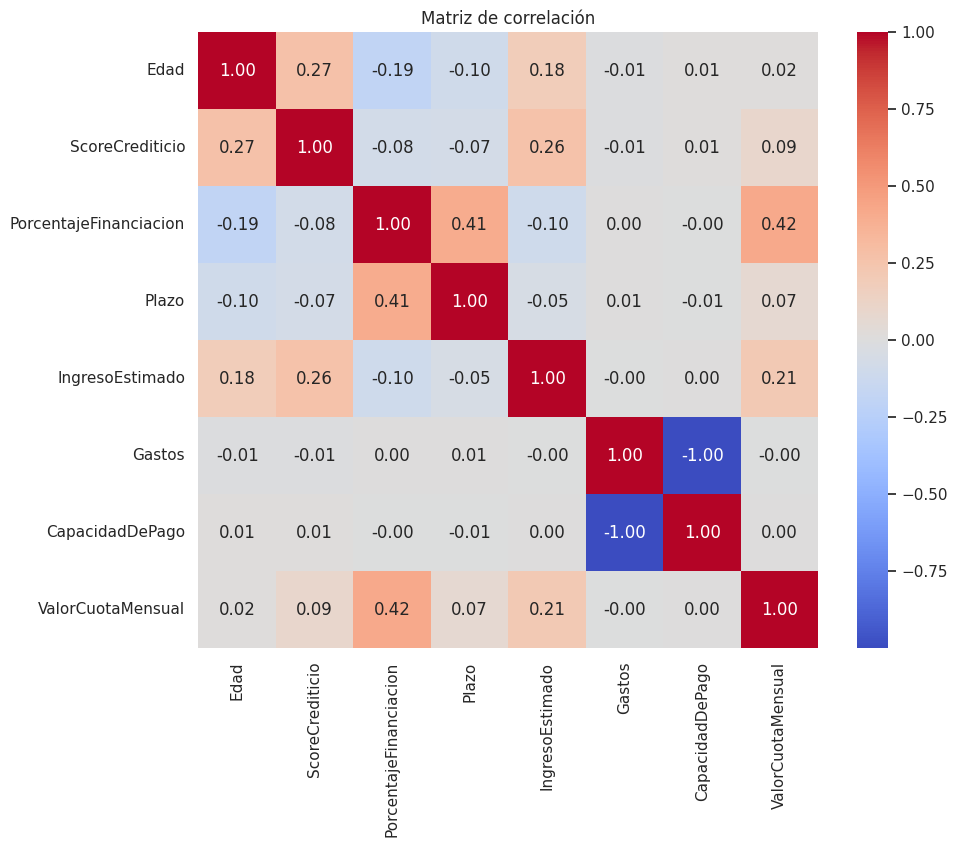

In [ ]:
num_cols = ['Edad',	'ScoreCrediticio', 'PorcentajeFinanciacion', 'Plazo', 'IngresoEstimado', 'Gastos', 'CapacidadDePago', 'ValorCuotaMensual']
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

# **2. Preprocesamiento**

## **2.1. Eliminación de filas y columnas**

Decidimos eliminar las filas en las que el Ingreso estimado fuera igual a cero, ya que el cero en este caso es equivalente a un valor faltante. Pero no es un simple valor faltante sino que, además, es un valor faltante que sesga el valor de otra columna (CapacidadDePago), ya que al parecer esta última está calculada con base en la relación Ingresos-Gastos.

Como consideramos que para el caso de análisis estas columnas pueden ser relevantes, preferimos descartar 1201 registros (5.7% del total de registros) que dejar sesgar el posible aporte de dos columnas. Cabe aclarar que antes de tomar esta decisión corroboramos que dicha eliminación no desequilibrara la proporción de registros en ambas clases de la variable objetivo (pensando en no perder registros valiosos de la clase minoritaria)

In [ ]:
temp = df.copy()
df = df[df['IngresoEstimado'] != 0]

Eiminamos la columna 'Caso' al tratarse de una columna con datos de tipo ID que no aportan ningún valor al modelo

In [ ]:
df = df.drop(['Caso'], axis=1)

##**2.2. Tratamiento de datos atípicos**

In [ ]:
vars_atypicals = ['ScoreCrediticio', 'IngresoEstimado', 'Gastos', 'CapacidadDePago', 'ValorCuotaMensual']

print(f"{'='*60}")
print("Valores descriptivos ANTES de Winsorización (Ej.: Gastos):")
print(f"{'='*60}\n")
print(df['Gastos'].describe())

# Aplicar Winsorización directamente en df
for col in vars_atypicals:
    lower_percentile = df[col].quantile(0.01)  # Percentil 1
    upper_percentile = df[col].quantile(0.99)  # Percentil 99

    df[col] = df[col].clip(lower=lower_percentile, upper=upper_percentile)

print(f"\n{'='*60}")
print("Valores descriptivos DESPUÉS de Winsorización (Ej.: Gastos):")
print(f"{'='*60}\n")
print(df['Gastos'].describe())
df[col] = df[col].clip(lower=lower_percentile, upper=upper_percentile)

Valores descriptivos ANTES de Winsorización (Ej.: Gastos):

count    1.986200e+04
mean     1.210194e+08
std      1.673056e+10
min      3.699731e+05
25%      1.086828e+06
50%      1.646024e+06
75%      2.683698e+06
max      2.357884e+12
Name: Gastos, dtype: float64

Valores descriptivos DESPUÉS de Winsorización (Ej.: Gastos):

count    1.986200e+04
mean     2.266693e+06
std      1.923529e+06
min      5.026228e+05
25%      1.086828e+06
50%      1.646024e+06
75%      2.683698e+06
max      1.164444e+07
Name: Gastos, dtype: float64


## **2.3. Transformación de variables categóricas**

In [ ]:
# Lista de variables categóricas a transformar
ohe_vars = ['Perfil', 'Estado', 'Genero']

# Generar las variables dummies para las columnas seleccionadas
df = pd.get_dummies(df, columns=ohe_vars, dtype=int, drop_first=True)
df.head()

,Edad,ScoreCrediticio,PorcentajeFinanciacion,Plazo,IngresoEstimado,Gastos,CapacidadDePago,ValorCuotaMensual,M3_30AC,Perfil_INDEPENDIENTE,Estado_USADO,Genero_MASCULINO
0,30,748,0.6850,72,3289800.0,2430508.51,0.361093,2379693.0,0,0,0,0
1,46,670,0.2783,60,2425440.0,1621788.08,0.948770,847046.0,0,1,0,1
2,39,752,1.0000,60,30000000.0,3614018.63,12.009213,2197145.0,0,1,1,1
3,38,758,1.0000,84,1631331.0,1725244.99,-0.068706,1366896.0,0,0,1,0
4,60,846,0.6596,72,20907400.0,3439341.88,13.004595,1343222.0,0,1,0,0


## **2.4. Estandarización de variables numéricas**

In [ ]:
df_sin_escalar = df.copy()

In [ ]:
# Almacenar variables númericas
zscore_vars = ['Edad','ScoreCrediticio', 'PorcentajeFinanciacion', 'Plazo','IngresoEstimado', 'Gastos', 'CapacidadDePago', 'ValorCuotaMensual']

# Escalamiento con Z-Score
scaler = StandardScaler()
for col in zscore_vars:
    df[[col]] = scaler.fit_transform(df[[col]])
df.head()

,Edad,ScoreCrediticio,PorcentajeFinanciacion,Plazo,IngresoEstimado,Gastos,CapacidadDePago,ValorCuotaMensual,M3_30AC,Perfil_INDEPENDIENTE,Estado_USADO,Genero_MASCULINO
0,-1.126014,-0.428605,-0.248437,0.910397,-0.340143,0.085166,-0.538558,0.842231,0,0,0,0
1,0.135263,-1.355057,-1.903812,-0.052465,-0.485571,-0.335280,-0.343106,-1.056826,0,1,0,1
2,-0.416545,-0.381095,1.033696,-0.052465,4.153843,0.700462,3.335418,0.616041,0,1,1,1
3,-0.495375,-0.309829,1.033696,1.873259,-0.619180,-0.281494,-0.681502,-0.412695,0,0,1,0
4,1.238881,0.735399,-0.351821,0.910397,2.624015,0.609649,3.666466,-0.442029,0,1,0,0


# **3. Balanceo de datos y división train/test**

## **3.1. Análisis del desbalance actual**


Clase 1 (Default):    782 registros (3.94%)
Clase 0 (No Default): 19,080 registros (96.06%)

Ratio de desbalance: 0.0:1


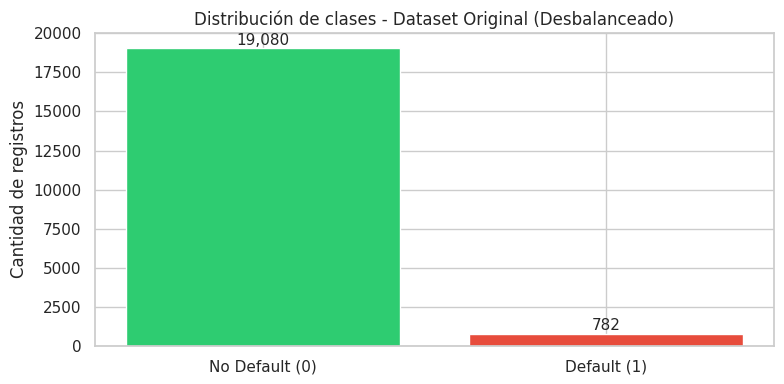

In [ ]:
distribucion = df['M3_30AC'].value_counts()
print(f"\nClase 1 (Default):    {distribucion[1]:,} registros ({distribucion[1]/len(df)*100:.2f}%)")
print(f"Clase 0 (No Default): {distribucion[0]:,} registros ({distribucion[0]/len(df)*100:.2f}%)")
print(f"\nRatio de desbalance: {distribucion[1]/distribucion[0]:.1f}:1")

# Visualización del desbalance
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(['No Default (0)', 'Default (1)'], [distribucion[0], distribucion[1]], color=colors)
ax.set_ylabel('Cantidad de registros')
ax.set_title('Distribución de clases - Dataset Original (Desbalanceado)')
for bar, val in zip(bars, [distribucion[0], distribucion[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, f'{val:,}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()


## **3.2. Separación de features y target**

In [ ]:
X = df.drop(columns=['M3_30AC'])
y = df['M3_30AC']

print(f"\nFeatures (X): {X.shape}")
print(f"Target (y):   {y.shape}")
print(f"\nColumnas de features: {list(X.columns)}")


Features (X): (19862, 11)
Target (y):   (19862,)

Columnas de features: ['Edad', 'ScoreCrediticio', 'PorcentajeFinanciacion', 'Plazo', 'IngresoEstimado', 'Gastos', 'CapacidadDePago', 'ValorCuotaMensual', 'Perfil_INDEPENDIENTE', 'Estado_USADO', 'Genero_MASCULINO']


## **3.3. División Train/Test ANTES del balanceo**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Mantener proporciones en ambos conjuntos
)

print(f"\nConjunto de entrenamiento: {X_train.shape[0]:,} registros")
print(f"Conjunto de prueba:        {X_test.shape[0]:,} registros")

print(f"\nDistribución en Train:")
print(f"  - Clase 1 (Default):    {(y_train==1).sum():,} ({(y_train==1).mean()*100:.2f}%)")
print(f"  - Clase 0 (No Default): {(y_train==0).sum():,} ({(y_train==0).mean()*100:.2f}%)")

print(f"\nDistribución en Test:")
print(f"  - Clase 1 (Default):    {(y_test==1).sum():,} ({(y_test==1).mean()*100:.2f}%)")
print(f"  - Clase 0 (No Default): {(y_test==0).sum():,} ({(y_test==0).mean()*100:.2f}%)")


Conjunto de entrenamiento: 15,889 registros
Conjunto de prueba:        3,973 registros

Distribución en Train:
  - Clase 1 (Default):    626 (3.94%)
  - Clase 0 (No Default): 15,263 (96.06%)

Distribución en Test:
  - Clase 1 (Default):    156 (3.93%)
  - Clase 0 (No Default): 3,817 (96.07%)


## **3.4. Balanceo mediante Undersampling (solo en Train)**



Antes del balanceo:
  - Clase 0: 15,263 registros
  - Clase 1: 626 registros

Después del balanceo:
  - Clase 0: 626 registros
  - Clase 1: 626 registros
  - Total:   1,252 registros


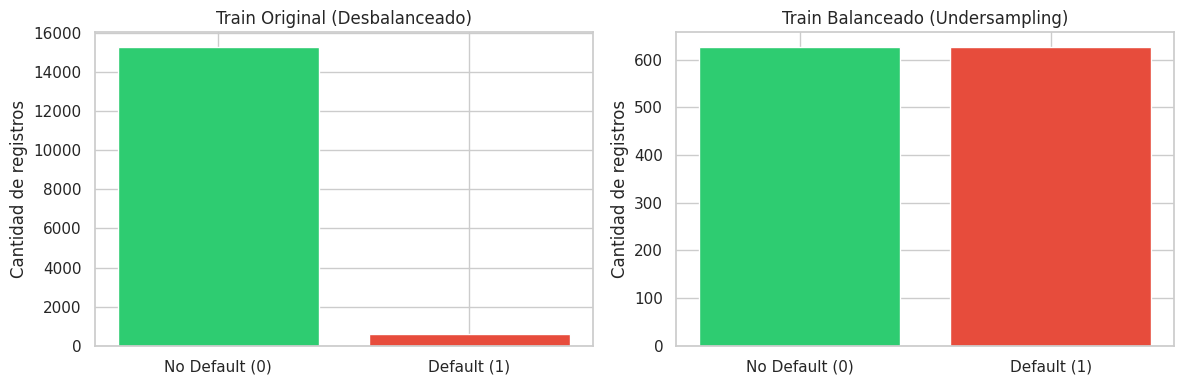

In [ ]:
# Unir X_train y y_train para hacer el muestreo
train_data = pd.concat([X_train, y_train], axis=1)

# Separar por clases
clase_0 = train_data[train_data['M3_30AC'] == 0]
clase_1 = train_data[train_data['M3_30AC'] == 1]

print(f"\nAntes del balanceo:")
print(f"  - Clase 0: {len(clase_0):,} registros")
print(f"  - Clase 1: {len(clase_1):,} registros")

# Submuestreo de la clase mayoritaria (0) para igualar a la minoritaria (1)
clase_0_submuestreada = clase_0.sample(n=len(clase_1), random_state=42)

# Unir las clases balanceadas
train_balanceado = pd.concat([clase_0_submuestreada, clase_1])
train_balanceado = train_balanceado.sample(frac=1, random_state=42).reset_index(drop=True)  # Mezclar

# Separar nuevamente en X e y
X_train_bal = train_balanceado.drop(columns=['M3_30AC'])
y_train_bal = train_balanceado['M3_30AC']

print(f"\nDespués del balanceo:")
print(f"  - Clase 0: {(y_train_bal==0).sum():,} registros")
print(f"  - Clase 1: {(y_train_bal==1).sum():,} registros")
print(f"  - Total:   {len(y_train_bal):,} registros")

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Train original
axes[0].bar(['No Default (0)', 'Default (1)'],
            [(y_train==0).sum(), (y_train==1).sum()],
            color=colors)
axes[0].set_title('Train Original (Desbalanceado)')
axes[0].set_ylabel('Cantidad de registros')

# Train balanceado
axes[1].bar(['No Default (0)', 'Default (1)'],
            [(y_train_bal==0).sum(), (y_train_bal==1).sum()],
            color=colors)
axes[1].set_title('Train Balanceado (Undersampling)')
axes[1].set_ylabel('Cantidad de registros')

plt.tight_layout()
plt.show()

## **3.5. Resumen de datasets disponibles**


In [ ]:
print("""
DATASETS PARA MODELADO:
───────────────────────────────────────────────────────────────
Dataset                  │ Variables        │ Registros
───────────────────────────────────────────────────────────────
X_train, y_train         │ Train Original   │ {:,} registros
X_train_bal, y_train_bal │ Train Balanceado │ {:,} registros
X_test, y_test           │ Test (sin tocar) │ {:,} registros
───────────────────────────────────────────────────────────────

NOTA: El conjunto de TEST nunca se balancea. Debe reflejar
      la distribución real para evaluar el modelo correctamente.
""".format(len(X_train), len(X_train_bal), len(X_test)))


DATASETS PARA MODELADO:
───────────────────────────────────────────────────────────────
Dataset                  │ Variables        │ Registros
───────────────────────────────────────────────────────────────
X_train, y_train         │ Train Original   │ 15,889 registros
X_train_bal, y_train_bal │ Train Balanceado │ 1,252 registros
X_test, y_test           │ Test (sin tocar) │ 3,973 registros
───────────────────────────────────────────────────────────────

NOTA: El conjunto de TEST nunca se balancea. Debe reflejar
      la distribución real para evaluar el modelo correctamente.



# **4. Modelo baseline MLP (red neuronal feedforward)**




## **4.1. Construcción del modelo baseline**

In [ ]:
# Fijar semillas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)


# Número de features de entrada
n_features = X_train_bal.shape[1]
print(f"\nNúmero de features de entrada: {n_features}")

modelo_baseline = Sequential([
    Input(shape=(n_features,)),
    Dense(16, activation='relu'),      # Capa oculta 1
    Dense(1, activation='sigmoid')     # Capa de salida (clasificación binaria)
])

modelo_baseline.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nArquitectura del modelo baseline:")
modelo_baseline.summary()



Número de features de entrada: 11

Arquitectura del modelo baseline:


Model: "sequential_178"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_521 (Dense)               │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_522 (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

## **4.2. Entrenamiento del modelo baseline**

In [ ]:
# Early stopping para evitar overfitting extremo
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Entrenar con datos balanceados
history_baseline = modelo_baseline.fit(
    X_train_bal, y_train_bal,
    epochs=100,
    batch_size=32,
    validation_split=0.2,  # 20% del train balanceado para validación
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4919 - loss: 0.7052 - val_accuracy: 0.5458 - val_loss: 0.6780
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5591 - loss: 0.6697 - val_accuracy: 0.6096 - val_loss: 0.6499
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6340 - loss: 0.6460 - val_accuracy: 0.6574 - val_loss: 0.6309
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6637 - loss: 0.6287 - val_accuracy: 0.7131 - val_loss: 0.6175
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6702 - loss: 0.6153 - val_accuracy: 0.7092 - val_loss: 0.6077
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6799 - loss: 0.6048 - val_accuracy: 0.7171 - val_loss: 0.6005
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6760 - loss: 0.5965 - val_accuracy: 0.7131 - val_loss: 0.5948
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6709 - loss: 0.5899 - val_accuracy: 0.7211 - 

## **4.3. Diagnóstico de Overfitting - Curvas de Loss**

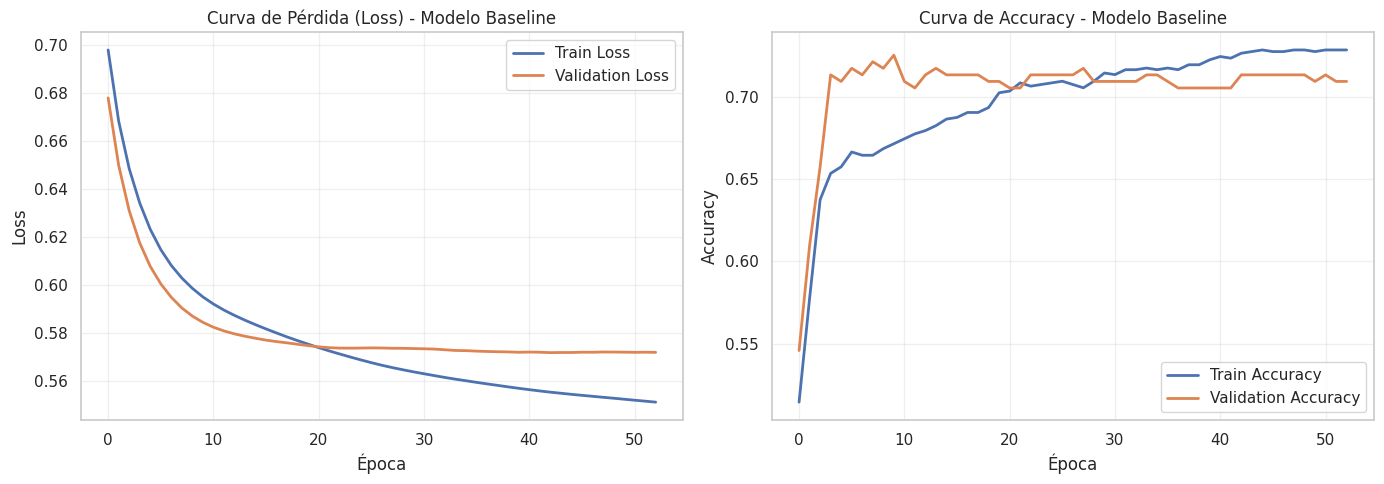


Loss final en Train:      0.5511
Loss final en Validation: 0.5718
Brecha (Val - Train):     0.0208

✅ DIAGNÓSTICO: El modelo parece generalizar adecuadamente


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de Loss
axes[0].plot(history_baseline.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_baseline.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Curva de Pérdida (Loss) - Modelo Baseline', fontsize=12)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Curva de Accuracy
axes[1].plot(history_baseline.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history_baseline.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Curva de Accuracy - Modelo Baseline', fontsize=12)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de overfitting
train_loss_final = history_baseline.history['loss'][-1]
val_loss_final = history_baseline.history['val_loss'][-1]
brecha_loss = val_loss_final - train_loss_final

print(f"\nLoss final en Train:      {train_loss_final:.4f}")
print(f"Loss final en Validation: {val_loss_final:.4f}")
print(f"Brecha (Val - Train):     {brecha_loss:.4f}")

if brecha_loss > 0.1:
    print("\n⚠️  DIAGNÓSTICO: Posible OVERFITTING detectado (brecha > 0.1)")
elif brecha_loss < -0.1:
    print("\n⚠️  DIAGNÓSTICO: Posible UNDERFITTING (modelo no aprende bien)")
else:
    print("\n✅ DIAGNÓSTICO: El modelo parece generalizar adecuadamente")

## **4.4. Evaluación del modelo baseline**


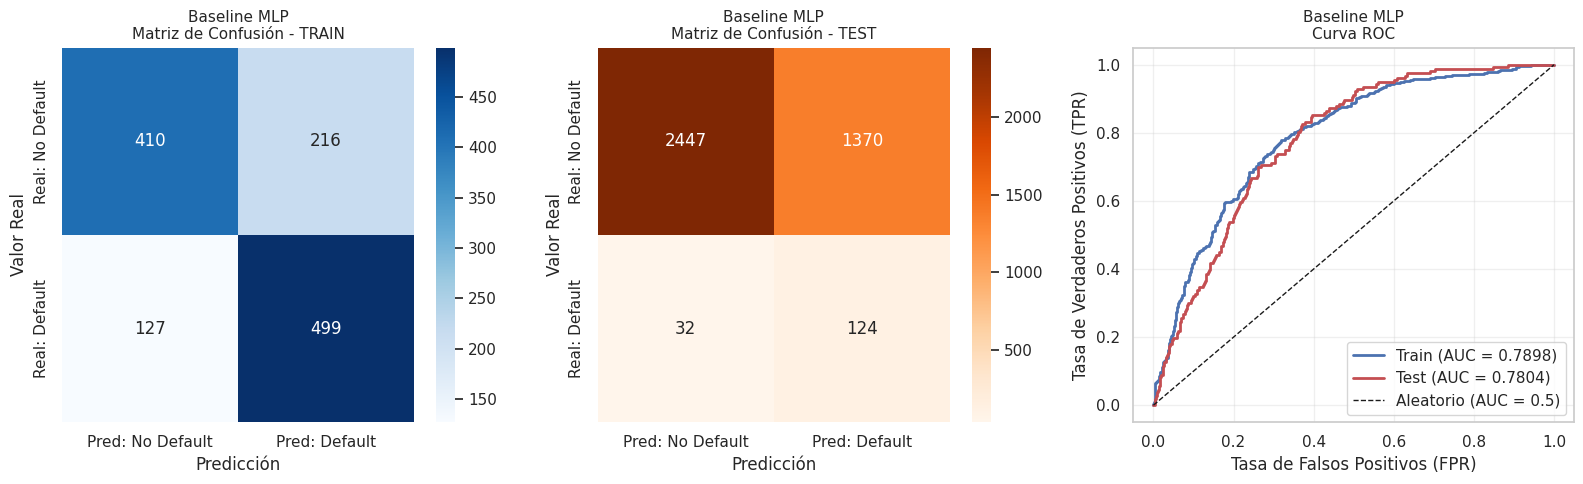


MÉTRICAS DE EVALUACIÓN - BASELINE MLP

Métrica                Train         Test
----------------------------------------
Accuracy              0.7260       0.6471
Precision             0.6979       0.0830
Recall                0.7971       0.7949
F1-Score              0.7442       0.1503
----------------------------------------
AUC-ROC               0.7898       0.7804

------------------------------------------------------------
INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN (TEST):
------------------------------------------------------------
  • Verdaderos Negativos (TN): 2,447 → Clientes buenos clasificados correctamente
  • Falsos Positivos (FP):     1,370 → Clientes buenos rechazados (error tipo I)
  • Falsos Negativos (FN):     32 → Clientes malos aprobados (error tipo II)
  • Verdaderos Positivos (TP): 124 → Clientes malos detectados correctamente

Brecha Accuracy (Train vs Test): 0.0789
Brecha F1-Score (Train vs Test): 0.5939

⚠️  Hay diferencia notable entre Train y Test → posible

In [ ]:
resultados_baseline = evaluar_modelo(
    modelo_baseline,
    X_train_bal, y_train_bal,  # Evaluamos en train balanceado
    X_test, y_test,            # Test original (desbalanceado, distribución real)
    nombre_modelo="Baseline MLP"
)


brecha_accuracy = abs(resultados_baseline['metricas']['Train']['Accuracy'] -
                      resultados_baseline['metricas']['Test']['Accuracy'])
brecha_f1 = abs(resultados_baseline['metricas']['Train']['F1-Score'] -
                resultados_baseline['metricas']['Test']['F1-Score'])

print(f"\nBrecha Accuracy (Train vs Test): {brecha_accuracy:.4f}")
print(f"Brecha F1-Score (Train vs Test): {brecha_f1:.4f}")

if brecha_accuracy > 0.1 or brecha_f1 > 0.1:
    print("\n⚠️  Hay diferencia notable entre Train y Test → posible overfitting")
else:
    print("\n✅ Las métricas son consistentes entre Train y Test")

# **5. Optimización de hiperparámetros - búsqueda aleatoria**

## **5.1. Definición del espacio de búsqueda**

In [ ]:
# Crear carpeta para guardar modelos
if not os.path.exists('modelos_guardados'):
    os.makedirs('modelos_guardados')

# -----------------------------------------------------------------------------
# Espacio de hiperparámetros a explorar
# -----------------------------------------------------------------------------
espacio_hiperparametros = {
    'capas': [
        [32],                    # 1 capa
        [64],                    # 1 capa más grande
        [32, 16],                # 2 capas (como baseline)
        [64, 32],                # 2 capas más grandes
        [64, 32, 16],            # 3 capas
        [128, 64, 32],           # 3 capas grandes
    ],
    'activacion': ['relu', 'tanh'],
    'learning_rate': [0.001, 0.01, 0.0005],
    'batch_size': [16, 32, 64],
    'dropout': [0.0, 0.2, 0.3],
    'optimizador': ['adam', 'rmsprop']
}

# Calcular total de combinaciones posibles
total_combinaciones = 1
for k, v in espacio_hiperparametros.items():
    total_combinaciones *= len(v)
print(f"\nTotal de combinaciones posibles: {total_combinaciones}")

# Seleccionamos N configuraciones aleatorias para probar
N_EXPERIMENTOS = 15
print(f"Configuraciones a evaluar: {N_EXPERIMENTOS}")

# Generar configuraciones aleatorias
np.random.seed(42)
configuraciones = []
for i in range(N_EXPERIMENTOS):
    config = {
        'capas': espacio_hiperparametros['capas'][np.random.randint(len(espacio_hiperparametros['capas']))],
        'activacion': espacio_hiperparametros['activacion'][np.random.randint(len(espacio_hiperparametros['activacion']))],
        'learning_rate': espacio_hiperparametros['learning_rate'][np.random.randint(len(espacio_hiperparametros['learning_rate']))],
        'batch_size': espacio_hiperparametros['batch_size'][np.random.randint(len(espacio_hiperparametros['batch_size']))],
        'dropout': espacio_hiperparametros['dropout'][np.random.randint(len(espacio_hiperparametros['dropout']))],
        'optimizador': espacio_hiperparametros['optimizador'][np.random.randint(len(espacio_hiperparametros['optimizador']))]
    }
    configuraciones.append(config)

print("\nConfiguraciones generadas:")
for i, cfg in enumerate(configuraciones):
    print(f"  [{i+1}] {cfg}")


Total de combinaciones posibles: 648
Configuraciones a evaluar: 15

Configuraciones generadas:
  [1] {'capas': [64, 32], 'activacion': 'relu', 'learning_rate': 0.0005, 'batch_size': 64, 'dropout': 0.0, 'optimizador': 'adam'}
  [2] {'capas': [64], 'activacion': 'relu', 'learning_rate': 0.0005, 'batch_size': 64, 'dropout': 0.3, 'optimizador': 'rmsprop'}
  [3] {'capas': [64, 32, 16], 'activacion': 'tanh', 'learning_rate': 0.0005, 'batch_size': 32, 'dropout': 0.0, 'optimizador': 'rmsprop'}
  [4] {'capas': [64, 32], 'activacion': 'tanh', 'learning_rate': 0.01, 'batch_size': 32, 'dropout': 0.0, 'optimizador': 'adam'}
  [5] {'capas': [64, 32], 'activacion': 'tanh', 'learning_rate': 0.01, 'batch_size': 16, 'dropout': 0.0, 'optimizador': 'adam'}
  [6] {'capas': [32, 16], 'activacion': 'relu', 'learning_rate': 0.0005, 'batch_size': 32, 'dropout': 0.3, 'optimizador': 'rmsprop'}
  [7] {'capas': [128, 64, 32], 'activacion': 'relu', 'learning_rate': 0.01, 'batch_size': 64, 'dropout': 0.3, 'optimiza

## **5.2. Entrenamiento de modelos**


MODELO 1/15
Configuración: {'capas': [64, 32], 'activacion': 'relu', 'learning_rate': 0.0005, 'batch_size': 64, 'dropout': 0.0, 'optimizador': 'adam'}

📊 MÉTRICAS:
   Métrica           Train       Test
   ----------------------------------
   Accuracy         0.7181     0.6340
   Precision        0.6878     0.0786
   Recall           0.7987     0.7756
   F1-Score         0.7391     0.1427
   AUC-ROC              --     0.7639

📋 Matriz Confusión Test: TN=2398, FP=1419, FN=35, TP=121
   → Morosos detectados: 121/156 (77.6%)
   → Clientes buenos rechazados: 1419/3817 (37.2%)

💾 Modelo guardado: modelo_1_capas64-32_actrelu_lr0.0005_bs64_drop0.0_optadam.keras


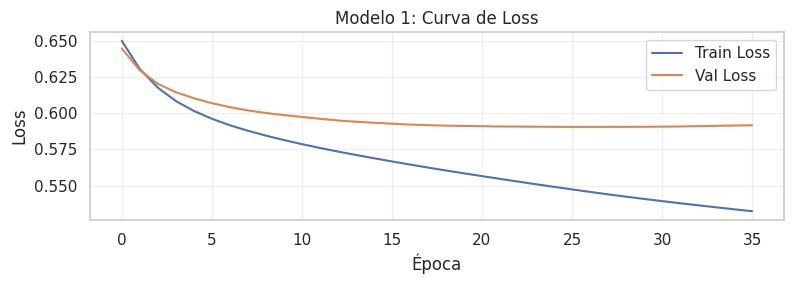


MODELO 2/15
Configuración: {'capas': [64], 'activacion': 'relu', 'learning_rate': 0.0005, 'batch_size': 64, 'dropout': 0.3, 'optimizador': 'rmsprop'}

📊 MÉTRICAS:
   Métrica           Train       Test
   ----------------------------------
   Accuracy         0.7204     0.6335
   Precision        0.6880     0.0790
   Recall           0.8067     0.7821
   F1-Score         0.7426     0.1435
   AUC-ROC              --     0.7721

📋 Matriz Confusión Test: TN=2395, FP=1422, FN=34, TP=122
   → Morosos detectados: 122/156 (78.2%)
   → Clientes buenos rechazados: 1422/3817 (37.3%)

💾 Modelo guardado: modelo_2_capas64_actrelu_lr0.0005_bs64_drop0.3_optrmsprop.keras


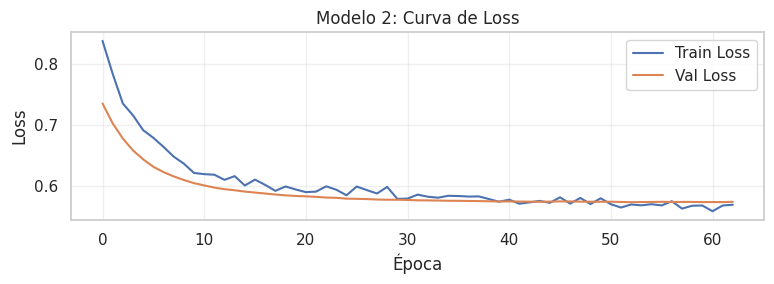


MODELO 3/15
Configuración: {'capas': [64, 32, 16], 'activacion': 'tanh', 'learning_rate': 0.0005, 'batch_size': 32, 'dropout': 0.0, 'optimizador': 'rmsprop'}

📊 MÉTRICAS:
   Métrica           Train       Test
   ----------------------------------
   Accuracy         0.7236     0.6602
   Precision        0.6972     0.0854
   Recall           0.7907     0.7885
   F1-Score         0.7410     0.1541
   AUC-ROC              --     0.7802

📋 Matriz Confusión Test: TN=2500, FP=1317, FN=33, TP=123
   → Morosos detectados: 123/156 (78.8%)
   → Clientes buenos rechazados: 1317/3817 (34.5%)

💾 Modelo guardado: modelo_3_capas64-32-16_acttanh_lr0.0005_bs32_drop0.0_optrmsprop.keras


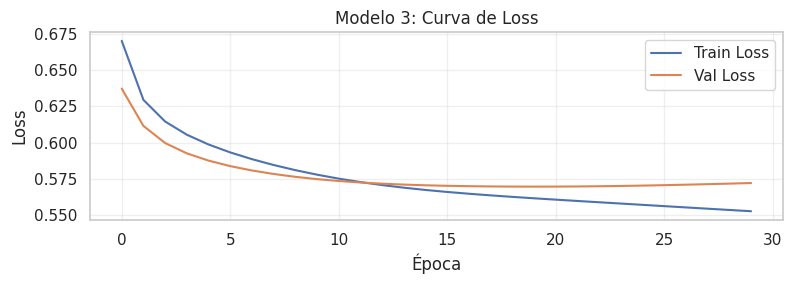


MODELO 4/15
Configuración: {'capas': [64, 32], 'activacion': 'tanh', 'learning_rate': 0.01, 'batch_size': 32, 'dropout': 0.0, 'optimizador': 'adam'}

📊 MÉTRICAS:
   Métrica           Train       Test
   ----------------------------------
   Accuracy         0.7101     0.6131
   Precision        0.6751     0.0751
   Recall           0.8099     0.7821
   F1-Score         0.7364     0.1370
   AUC-ROC              --     0.7692

📋 Matriz Confusión Test: TN=2314, FP=1503, FN=34, TP=122
   → Morosos detectados: 122/156 (78.2%)
   → Clientes buenos rechazados: 1503/3817 (39.4%)

💾 Modelo guardado: modelo_4_capas64-32_acttanh_lr0.01_bs32_drop0.0_optadam.keras


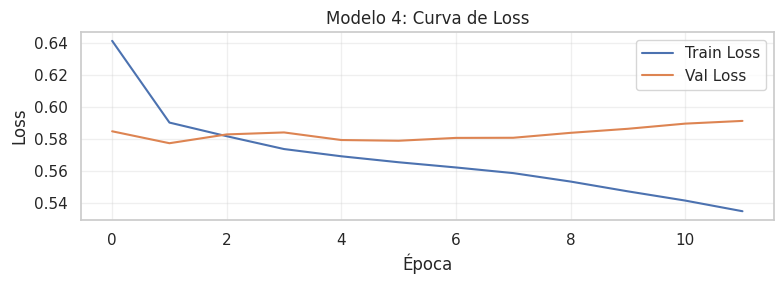


MODELO 5/15
Configuración: {'capas': [64, 32], 'activacion': 'tanh', 'learning_rate': 0.01, 'batch_size': 16, 'dropout': 0.0, 'optimizador': 'adam'}

📊 MÉTRICAS:
   Métrica           Train       Test
   ----------------------------------
   Accuracy         0.7141     0.6046
   Precision        0.6763     0.0771
   Recall           0.8211     0.8269
   F1-Score         0.7417     0.1411
   AUC-ROC              --     0.7671

📋 Matriz Confusión Test: TN=2273, FP=1544, FN=27, TP=129
   → Morosos detectados: 129/156 (82.7%)
   → Clientes buenos rechazados: 1544/3817 (40.5%)

💾 Modelo guardado: modelo_5_capas64-32_acttanh_lr0.01_bs16_drop0.0_optadam.keras


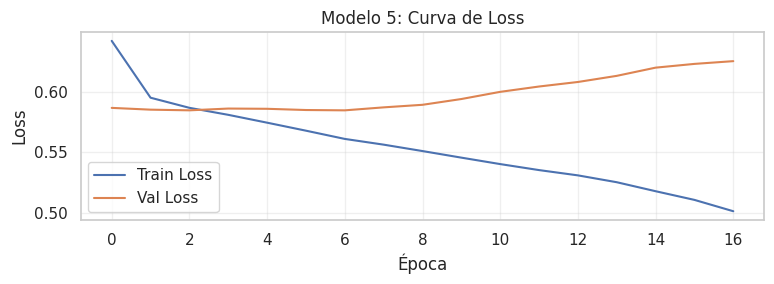


MODELO 6/15
Configuración: {'capas': [32, 16], 'activacion': 'relu', 'learning_rate': 0.0005, 'batch_size': 32, 'dropout': 0.3, 'optimizador': 'rmsprop'}

📊 MÉTRICAS:
   Métrica           Train       Test
   ----------------------------------
   Accuracy         0.7268     0.6381
   Precision        0.6929     0.0810
   Recall           0.8147     0.7949
   F1-Score         0.7489     0.1471
   AUC-ROC              --     0.7753

📋 Matriz Confusión Test: TN=2411, FP=1406, FN=32, TP=124
   → Morosos detectados: 124/156 (79.5%)
   → Clientes buenos rechazados: 1406/3817 (36.8%)

💾 Modelo guardado: modelo_6_capas32-16_actrelu_lr0.0005_bs32_drop0.3_optrmsprop.keras


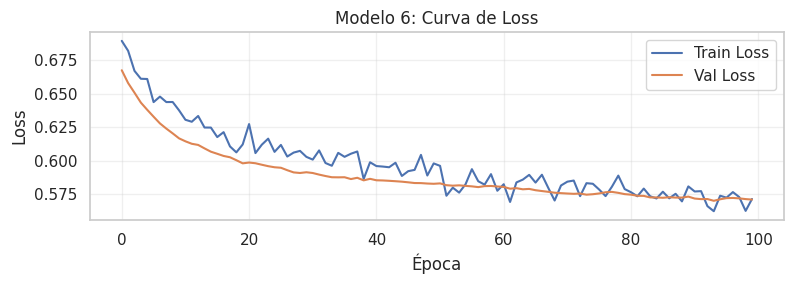


MODELO 7/15
Configuración: {'capas': [128, 64, 32], 'activacion': 'relu', 'learning_rate': 0.01, 'batch_size': 64, 'dropout': 0.3, 'optimizador': 'rmsprop'}

📊 MÉTRICAS:
   Métrica           Train       Test
   ----------------------------------
   Accuracy         0.7396     0.6043
   Precision        0.6995     0.0750
   Recall           0.8403     0.8013
   F1-Score         0.7634     0.1372
   AUC-ROC              --     0.7523

📋 Matriz Confusión Test: TN=2276, FP=1541, FN=31, TP=125
   → Morosos detectados: 125/156 (80.1%)
   → Clientes buenos rechazados: 1541/3817 (40.4%)

💾 Modelo guardado: modelo_7_capas128-64-32_actrelu_lr0.01_bs64_drop0.3_optrmsprop.keras


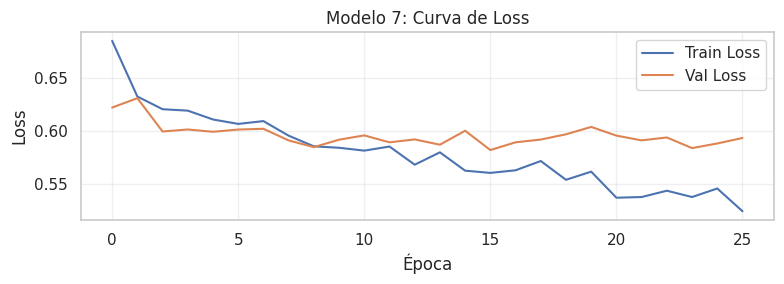


MODELO 8/15
Configuración: {'capas': [32], 'activacion': 'relu', 'learning_rate': 0.001, 'batch_size': 64, 'dropout': 0.3, 'optimizador': 'adam'}

📊 MÉTRICAS:
   Métrica           Train       Test
   ----------------------------------
   Accuracy         0.7204     0.6509
   Precision        0.6922     0.0838
   Recall           0.7939     0.7949
   F1-Score         0.7396     0.1517
   AUC-ROC              --     0.7748

📋 Matriz Confusión Test: TN=2462, FP=1355, FN=32, TP=124
   → Morosos detectados: 124/156 (79.5%)
   → Clientes buenos rechazados: 1355/3817 (35.5%)

💾 Modelo guardado: modelo_8_capas32_actrelu_lr0.001_bs64_drop0.3_optadam.keras


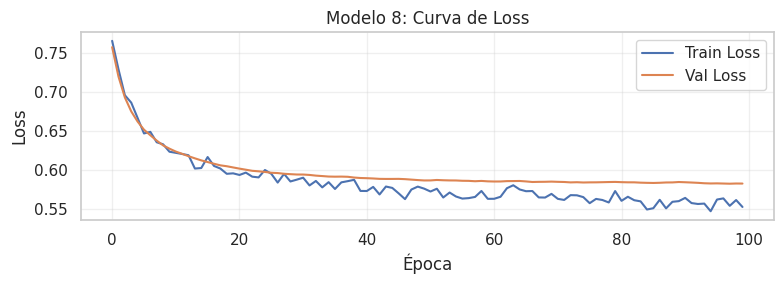


MODELO 9/15
Configuración: {'capas': [32], 'activacion': 'relu', 'learning_rate': 0.01, 'batch_size': 16, 'dropout': 0.2, 'optimizador': 'rmsprop'}

📊 MÉTRICAS:
   Métrica           Train       Test
   ----------------------------------
   Accuracy         0.7332     0.6280
   Precision        0.7017     0.0801
   Recall           0.8115     0.8077
   F1-Score         0.7526     0.1457
   AUC-ROC              --     0.7575

📋 Matriz Confusión Test: TN=2369, FP=1448, FN=30, TP=126
   → Morosos detectados: 126/156 (80.8%)
   → Clientes buenos rechazados: 1448/3817 (37.9%)

💾 Modelo guardado: modelo_9_capas32_actrelu_lr0.01_bs16_drop0.2_optrmsprop.keras


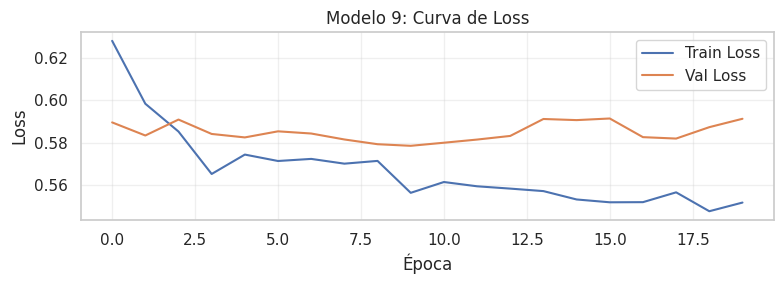


MODELO 10/15
Configuración: {'capas': [64], 'activacion': 'relu', 'learning_rate': 0.01, 'batch_size': 16, 'dropout': 0.2, 'optimizador': 'rmsprop'}

📊 MÉTRICAS:
   Métrica           Train       Test
   ----------------------------------
   Accuracy         0.7340     0.6587
   Precision        0.7190     0.0828
   Recall           0.7684     0.7628
   F1-Score         0.7429     0.1493
   AUC-ROC              --     0.7594

📋 Matriz Confusión Test: TN=2498, FP=1319, FN=37, TP=119
   → Morosos detectados: 119/156 (76.3%)
   → Clientes buenos rechazados: 1319/3817 (34.6%)

💾 Modelo guardado: modelo_10_capas64_actrelu_lr0.01_bs16_drop0.2_optrmsprop.keras


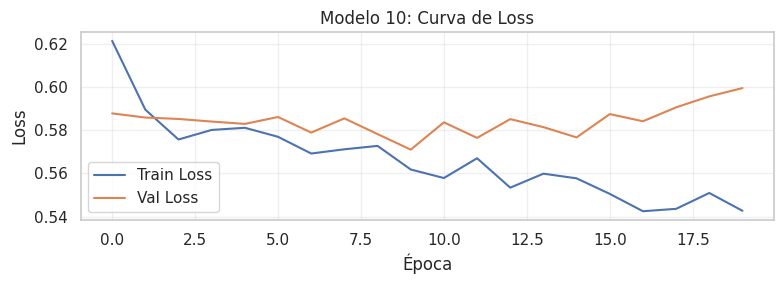


MODELO 11/15
Configuración: {'capas': [64, 32], 'activacion': 'relu', 'learning_rate': 0.0005, 'batch_size': 16, 'dropout': 0.3, 'optimizador': 'adam'}

📊 MÉTRICAS:
   Métrica           Train       Test
   ----------------------------------
   Accuracy         0.7292     0.6481
   Precision        0.7041     0.0832
   Recall           0.7907     0.7949
   F1-Score         0.7449     0.1507
   AUC-ROC              --     0.7705

📋 Matriz Confusión Test: TN=2451, FP=1366, FN=32, TP=124
   → Morosos detectados: 124/156 (79.5%)
   → Clientes buenos rechazados: 1366/3817 (35.8%)

💾 Modelo guardado: modelo_11_capas64-32_actrelu_lr0.0005_bs16_drop0.3_optadam.keras


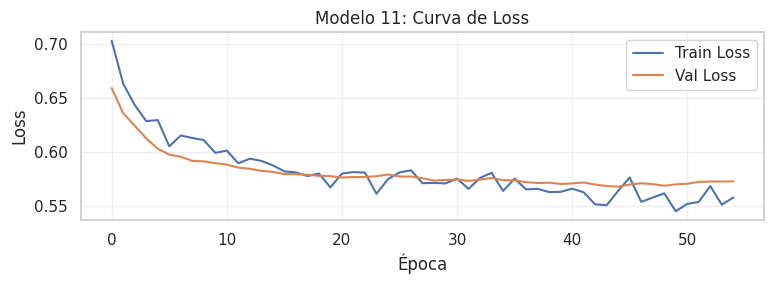


MODELO 12/15
Configuración: {'capas': [128, 64, 32], 'activacion': 'relu', 'learning_rate': 0.01, 'batch_size': 32, 'dropout': 0.2, 'optimizador': 'rmsprop'}

📊 MÉTRICAS:
   Métrica           Train       Test
   ----------------------------------
   Accuracy         0.7292     0.6595
   Precision        0.7047     0.0841
   Recall           0.7891     0.7756
   F1-Score         0.7445     0.1517
   AUC-ROC              --     0.7595

📋 Matriz Confusión Test: TN=2499, FP=1318, FN=35, TP=121
   → Morosos detectados: 121/156 (77.6%)
   → Clientes buenos rechazados: 1318/3817 (34.5%)

💾 Modelo guardado: modelo_12_capas128-64-32_actrelu_lr0.01_bs32_drop0.2_optrmsprop.keras


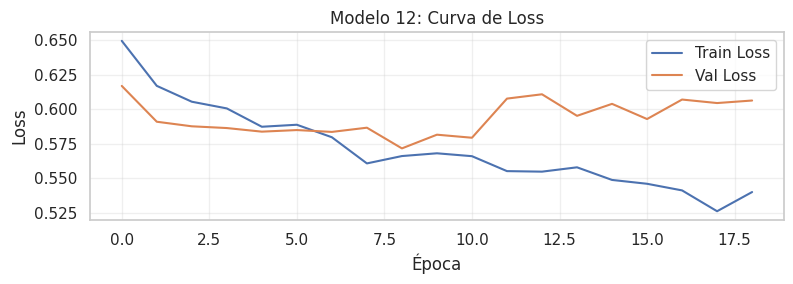


MODELO 13/15
Configuración: {'capas': [128, 64, 32], 'activacion': 'tanh', 'learning_rate': 0.01, 'batch_size': 16, 'dropout': 0.3, 'optimizador': 'rmsprop'}

📊 MÉTRICAS:
   Métrica           Train       Test
   ----------------------------------
   Accuracy         0.7173     0.6071
   Precision        0.6813     0.0766
   Recall           0.8163     0.8141
   F1-Score         0.7427     0.1399
   AUC-ROC              --     0.7662

📋 Matriz Confusión Test: TN=2285, FP=1532, FN=29, TP=127
   → Morosos detectados: 127/156 (81.4%)
   → Clientes buenos rechazados: 1532/3817 (40.1%)

💾 Modelo guardado: modelo_13_capas128-64-32_acttanh_lr0.01_bs16_drop0.3_optrmsprop.keras


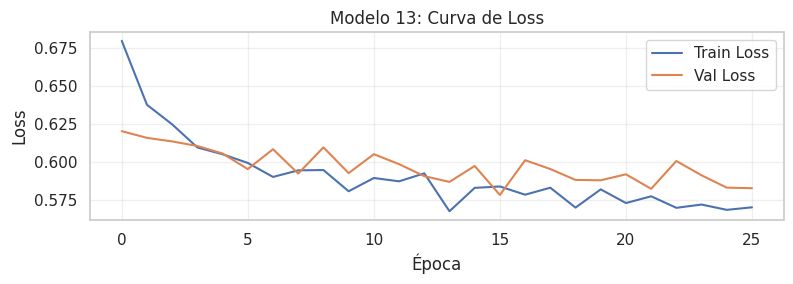


MODELO 14/15
Configuración: {'capas': [64], 'activacion': 'tanh', 'learning_rate': 0.01, 'batch_size': 32, 'dropout': 0.2, 'optimizador': 'rmsprop'}

📊 MÉTRICAS:
   Métrica           Train       Test
   ----------------------------------
   Accuracy         0.7133     0.6232
   Precision        0.6821     0.0807
   Recall           0.7987     0.8269
   F1-Score         0.7358     0.1470
   AUC-ROC              --     0.7814

📋 Matriz Confusión Test: TN=2347, FP=1470, FN=27, TP=129
   → Morosos detectados: 129/156 (82.7%)
   → Clientes buenos rechazados: 1470/3817 (38.5%)

💾 Modelo guardado: modelo_14_capas64_acttanh_lr0.01_bs32_drop0.2_optrmsprop.keras


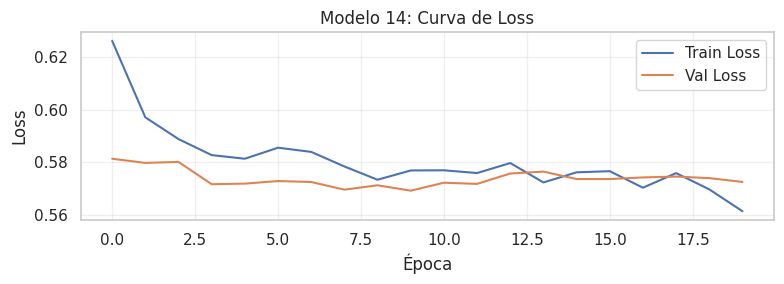


MODELO 15/15
Configuración: {'capas': [128, 64, 32], 'activacion': 'relu', 'learning_rate': 0.0005, 'batch_size': 32, 'dropout': 0.3, 'optimizador': 'rmsprop'}

📊 MÉTRICAS:
   Métrica           Train       Test
   ----------------------------------
   Accuracy         0.7125     0.5993
   Precision        0.6714     0.0762
   Recall           0.8323     0.8269
   F1-Score         0.7432     0.1395
   AUC-ROC              --     0.7687

📋 Matriz Confusión Test: TN=2252, FP=1565, FN=27, TP=129
   → Morosos detectados: 129/156 (82.7%)
   → Clientes buenos rechazados: 1565/3817 (41.0%)

💾 Modelo guardado: modelo_15_capas128-64-32_actrelu_lr0.0005_bs32_drop0.3_optrmsprop.keras


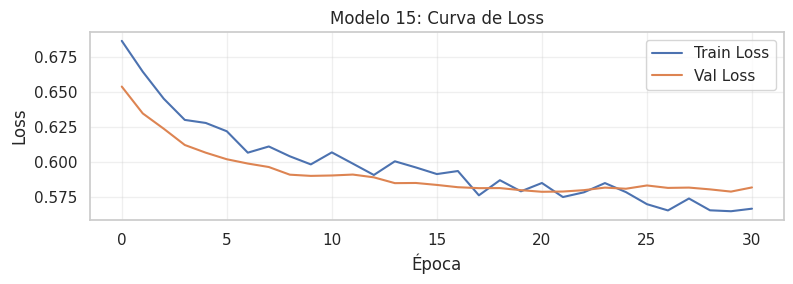

In [ ]:
# Establecer semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Almacenar resultados
resultados_busqueda = []
modelos_entrenados = {}

n_features = X_train_bal.shape[1]

for idx, config in enumerate(configuraciones):
    print(f"\n{'='*60}")
    print(f"MODELO {idx+1}/{N_EXPERIMENTOS}")
    print(f"{'='*60}")
    print(f"Configuración: {config}")

    # Crear modelo
    modelo = crear_modelo(config, n_features)

    # Early stopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=0
    )

    # Entrenar
    history = modelo.fit(
        X_train_bal, y_train_bal,
        epochs=100,
        batch_size=config['batch_size'],
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )

    # Predicciones
    y_train_pred = (modelo.predict(X_train_bal, verbose=0) >= 0.5).astype(int).flatten()
    y_test_pred = (modelo.predict(X_test, verbose=0) >= 0.5).astype(int).flatten()
    y_test_pred_prob = modelo.predict(X_test, verbose=0).flatten()

    # Métricas
    metricas_train = {
        'accuracy': accuracy_score(y_train_bal, y_train_pred),
        'precision': precision_score(y_train_bal, y_train_pred, zero_division=0),
        'recall': recall_score(y_train_bal, y_train_pred, zero_division=0),
        'f1': f1_score(y_train_bal, y_train_pred, zero_division=0)
    }

    metricas_test = {
        'accuracy': accuracy_score(y_test, y_test_pred),
        'precision': precision_score(y_test, y_test_pred, zero_division=0),
        'recall': recall_score(y_test, y_test_pred, zero_division=0),
        'f1': f1_score(y_test, y_test_pred, zero_division=0)
    }

    # AUC
    fpr, tpr, _ = roc_curve(y_test, y_test_pred_prob)
    auc_test = auc(fpr, tpr)

    # Matriz de confusión test
    cm_test = confusion_matrix(y_test, y_test_pred)
    tn, fp, fn, tp = cm_test.ravel()

    # Mostrar resultados
    print(f"\n📊 MÉTRICAS:")
    print(f"   {'Métrica':<12} {'Train':>10} {'Test':>10}")
    print(f"   {'-'*34}")
    print(f"   {'Accuracy':<12} {metricas_train['accuracy']:>10.4f} {metricas_test['accuracy']:>10.4f}")
    print(f"   {'Precision':<12} {metricas_train['precision']:>10.4f} {metricas_test['precision']:>10.4f}")
    print(f"   {'Recall':<12} {metricas_train['recall']:>10.4f} {metricas_test['recall']:>10.4f}")
    print(f"   {'F1-Score':<12} {metricas_train['f1']:>10.4f} {metricas_test['f1']:>10.4f}")
    print(f"   {'AUC-ROC':<12} {'--':>10} {auc_test:>10.4f}")

    print(f"\n📋 Matriz Confusión Test: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(f"   → Morosos detectados: {tp}/{tp+fn} ({tp/(tp+fn)*100:.1f}%)")
    print(f"   → Clientes buenos rechazados: {fp}/{tn+fp} ({fp/(tn+fp)*100:.1f}%)")

    # Guardar modelo
    nombre_modelo = f"modelo_{idx+1}_{config_to_string(config)}"
    modelo.save(f"modelos_guardados/{nombre_modelo}.keras")
    print(f"\n💾 Modelo guardado: {nombre_modelo}.keras")

    # Guardar resultados
    resultados_busqueda.append({
        'modelo_id': idx + 1,
        'config': config,
        'nombre': nombre_modelo,
        'train_accuracy': metricas_train['accuracy'],
        'train_precision': metricas_train['precision'],
        'train_recall': metricas_train['recall'],
        'train_f1': metricas_train['f1'],
        'test_accuracy': metricas_test['accuracy'],
        'test_precision': metricas_test['precision'],
        'test_recall': metricas_test['recall'],
        'test_f1': metricas_test['f1'],
        'test_auc': auc_test,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'epochs': len(history.history['loss'])
    })

    modelos_entrenados[idx + 1] = modelo

    # Gráfico de loss
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(history.history['loss'], label='Train Loss')
    ax.plot(history.history['val_loss'], label='Val Loss')
    ax.set_title(f'Modelo {idx+1}: Curva de Loss')
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## **5.3. Resumen comparativo**



 modelo_id  test_accuracy  test_precision  test_recall  test_f1  test_auc  FN   FP
         1       0.634030        0.078571     0.775641 0.142689  0.763904  35 1419
         2       0.633526        0.079016     0.782051 0.143529  0.772059  34 1422
         3       0.660206        0.085417     0.788462 0.154135  0.780160  33 1317
         4       0.613139        0.075077     0.782051 0.137002  0.769246  34 1503
         5       0.604581        0.077107     0.826923 0.141061  0.767078  27 1544
         6       0.638057        0.081046     0.794872 0.147094  0.775267  32 1406
         7       0.604329        0.075030     0.801282 0.137212  0.752302  31 1541
         8       0.650894        0.083840     0.794872 0.151682  0.774781  32 1355
         9       0.627989        0.080051     0.807692 0.145665  0.757544  30 1448
        10       0.658696        0.082754     0.762821 0.149310  0.759396  37 1319
        11       0.648125        0.083221     0.794872 0.150668  0.770541  32 1366
  

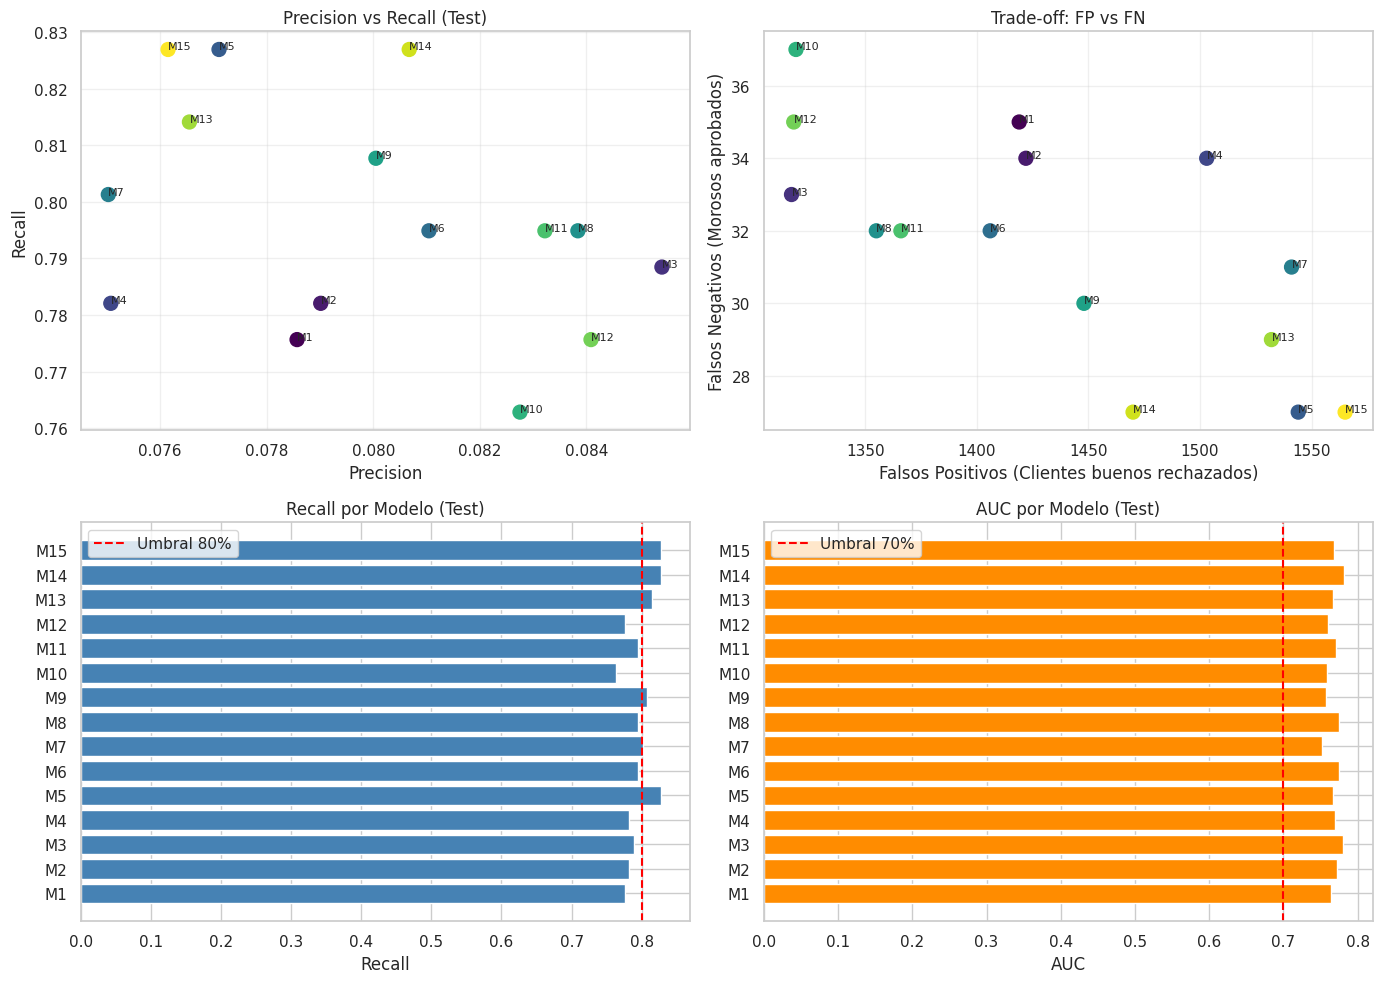


💾 Resultados guardados en 'resultados_busqueda_hiperparametros.csv'


In [ ]:
# Crear DataFrame con resultados
df_resultados = pd.DataFrame(resultados_busqueda)

# Mostrar tabla resumida
cols_mostrar = ['modelo_id', 'test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_auc', 'FN', 'FP']
print("\n")
print(df_resultados[cols_mostrar].to_string(index=False))

# -----------------------------------------------------------------------------
# Análisis por criterio de negocio
# -----------------------------------------------------------------------------
print("\n" + "=" * 60)
print("5.4. RANKING POR CRITERIOS DE NEGOCIO")
print("=" * 60)

# Criterio 1: Maximizar Recall (detectar más morosos)
print("\n🎯 TOP 5 - MAYOR RECALL (detectar más morosos):")
top_recall = df_resultados.nlargest(5, 'test_recall')[['modelo_id', 'test_recall', 'test_precision', 'FN', 'FP']]
print(top_recall.to_string(index=False))

# Criterio 2: Minimizar Falsos Negativos (morosos aprobados)
print("\n💰 TOP 5 - MENOR FN (menos morosos aprobados):")
top_fn = df_resultados.nsmallest(5, 'FN')[['modelo_id', 'FN', 'test_recall', 'FP']]
print(top_fn.to_string(index=False))

# Criterio 3: Balance (mejor F1)
print("\n⚖️ TOP 5 - MEJOR F1-SCORE (balance precision-recall):")
top_f1 = df_resultados.nlargest(5, 'test_f1')[['modelo_id', 'test_f1', 'test_precision', 'test_recall']]
print(top_f1.to_string(index=False))

# Criterio 4: Mayor AUC
print("\n📈 TOP 5 - MAYOR AUC:")
top_auc = df_resultados.nlargest(5, 'test_auc')[['modelo_id', 'test_auc', 'test_recall', 'test_precision']]
print(top_auc.to_string(index=False))

# -----------------------------------------------------------------------------
# Visualización comparativa
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Recall vs Precision
axes[0, 0].scatter(df_resultados['test_precision'], df_resultados['test_recall'],
                   c=df_resultados['modelo_id'], cmap='viridis', s=100)
for i, row in df_resultados.iterrows():
    axes[0, 0].annotate(f"M{row['modelo_id']}", (row['test_precision'], row['test_recall']), fontsize=8)
axes[0, 0].set_xlabel('Precision')
axes[0, 0].set_ylabel('Recall')
axes[0, 0].set_title('Precision vs Recall (Test)')
axes[0, 0].grid(True, alpha=0.3)

# FN vs FP
axes[0, 1].scatter(df_resultados['FP'], df_resultados['FN'],
                   c=df_resultados['modelo_id'], cmap='viridis', s=100)
for i, row in df_resultados.iterrows():
    axes[0, 1].annotate(f"M{row['modelo_id']}", (row['FP'], row['FN']), fontsize=8)
axes[0, 1].set_xlabel('Falsos Positivos (Clientes buenos rechazados)')
axes[0, 1].set_ylabel('Falsos Negativos (Morosos aprobados)')
axes[0, 1].set_title('Trade-off: FP vs FN')
axes[0, 1].grid(True, alpha=0.3)

# Barras de Recall
axes[1, 0].barh([f"M{x}" for x in df_resultados['modelo_id']], df_resultados['test_recall'], color='steelblue')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_title('Recall por Modelo (Test)')
axes[1, 0].axvline(x=0.8, color='red', linestyle='--', label='Umbral 80%')
axes[1, 0].legend()

# Barras de AUC
axes[1, 1].barh([f"M{x}" for x in df_resultados['modelo_id']], df_resultados['test_auc'], color='darkorange')
axes[1, 1].set_xlabel('AUC')
axes[1, 1].set_title('AUC por Modelo (Test)')
axes[1, 1].axvline(x=0.7, color='red', linestyle='--', label='Umbral 70%')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# Guardar resultados en CSV
# -----------------------------------------------------------------------------
df_resultados.to_csv('resultados_busqueda_hiperparametros.csv', index=False)
print("\n💾 Resultados guardados en 'resultados_busqueda_hiperparametros.csv'")

# **6. Justificación del criterio de éxito**

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║          ¿RECALL ALTO O PRECISIÓN ALTA? - ANÁLISIS DE NEGOCIO        ║
╚══════════════════════════════════════════════════════════════════════╝

CONTEXTO:
─────────────────────────────────────────────────────────────────────────
Un concesionario otorga créditos para la compra de vehículos. Cuando un
cliente incumple (default), el concesionario enfrenta:
  • Costos de recuperación de cartera
  • Posible pérdida total o parcial del capital prestado
  • Costos legales y administrativos
  • Depreciación del vehículo recuperado

═══════════════════════════════════════════════════════════════════════
                    ANÁLISIS DE LOS DOS ENFOQUES
═══════════════════════════════════════════════════════════════════════

┌─────────────────────────────────────────────────────────────────────┐
│  OPCIÓN A: PRIORIZAR RECALL ALTO (Minimizar Falsos Negativos)       │
├─────────────────────────────────────────────────────────────────────┤
│  • Objetivo: Detectar la MAYOR cantidad posible de morosos          │
│  • FN bajo = Pocos morosos aprobados = Menor pérdida financiera     │
│  • Consecuencia: Mayor cantidad de FP (clientes buenos rechazados)  │
│                                                                     │
│  COSTOS:                                                            │
│    - Se pierden ventas a clientes que SÍ habrían pagado             │
│    - Menor volumen de operaciones                                   │
│    - Posible daño reputacional ("rechazan a todos")                 │
│                                                                     │
│  BENEFICIOS:                                                        │
│    - Cartera más sana                                               │
│    - Menor riesgo de pérdidas por incumplimiento                    │
│    - Flujo de caja más predecible                                   │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│  OPCIÓN B: PRIORIZAR PRECISIÓN ALTA (Minimizar Falsos Positivos)    │
├─────────────────────────────────────────────────────────────────────┤
│  • Objetivo: No rechazar clientes que SÍ pagarían                   │
│  • FP bajo = Pocos buenos rechazados = Más ventas                   │
│  • Consecuencia: Mayor cantidad de FN (más morosos aprobados)       │
│                                                                     │
│  COSTOS:                                                            │
│    - Mayor exposición al riesgo de incumplimiento                   │
│    - Posibles pérdidas financieras significativas                   │
│    - Cartera con mayor morosidad                                    │
│                                                                     │
│  BENEFICIOS:                                                        │
│    - Mayor volumen de ventas                                        │
│    - Más clientes atendidos                                         │
│    - Potencial mayor ingreso bruto                                  │
└─────────────────────────────────────────────────────────────────────┘

═══════════════════════════════════════════════════════════════════════
                         NUESTRA RECOMENDACIÓN
═══════════════════════════════════════════════════════════════════════

  ➤ PRIORIZAR: RECALL ALTO (Opción A)

  ➤ CLASE DE ENFOQUE: Clase 1 (Default/Incumplimiento)

═══════════════════════════════════════════════════════════════════════
                            JUSTIFICACIÓN
═══════════════════════════════════════════════════════════════════════

1. ASIMETRÍA DE COSTOS:
   ─────────────────────
   El costo de un Falso Negativo (aprobar a un moroso) es
   significativamente MAYOR que el costo de un Falso Positivo
   (rechazar a un buen cliente).

   • FN: Pérdida potencial = Valor del crédito (millones de pesos)
   • FP: Pérdida potencial = Margen de ganancia de una venta

   Ejemplo numérico:
   - Valor promedio de un vehículo financiado: $50,000,000 COP
   - Margen de ganancia por venta: ~$5,000,000 COP
   - Ratio de costo FN/FP ≈ 10:1

   → Un moroso aprobado cuesta lo mismo que ~10 ventas perdidas

2. NATURALEZA DEL NEGOCIO CREDITICIO:
   ───────────────────────────────────
   En el sector financiero, la gestión del riesgo es primordial.
   Una cartera con alta morosidad puede:
   • Afectar la liquidez del concesionario
   • Aumentar costos operativos de cobranza
   • Deteriorar indicadores financieros
   • Limitar acceso a financiamiento propio

3. CLIENTES RECHAZADOS NO SON PÉRDIDAS DEFINITIVAS:
   ─────────────────────────────────────────────────
   Un cliente "bueno" rechazado por el modelo puede:
   • Ser evaluado manualmente con documentación adicional
   • Acceder a un crédito con condiciones diferentes (mayor cuota inicial)
   • Regresar cuando mejore su perfil crediticio

   En cambio, un moroso aprobado genera pérdida casi segura.

4. CONTEXTO DE LOS DATOS:
   ───────────────────────
   La base muestra que solo ~4% de los clientes caen en default.
   Esto significa que el modelo debe ser especialmente sensible
   para detectar esta minoría de alto riesgo.

═══════════════════════════════════════════════════════════════════════
                      MÉTRICA PRINCIPAL DE ÉXITO
═══════════════════════════════════════════════════════════════════════

  ┌───────────────────────────────────────────────────────────────────┐
  │                                                                   │
  │   RECALL DE LA CLASE 1 (DEFAULT) ≥ 80%                            │
  │                                                                   │
  │   Interpretación: Detectar al menos 8 de cada 10 clientes         │
  │   que van a incumplir, aceptando un nivel moderado de             │
  │   falsos positivos.                                               │
  │                                                                   │
  │   Métrica secundaria: AUC-ROC ≥ 0.75 (capacidad discriminativa)   │
  │                                                                   │
  └───────────────────────────────────────────────────────────────────┘

═══════════════════════════════════════════════════════════════════════
                    ESTRATEGIA DE IMPLEMENTACIÓN
═══════════════════════════════════════════════════════════════════════

  Se recomienda un SISTEMA DE DOS ETAPAS:

  ETAPA 1 - FILTRO AUTOMÁTICO (Modelo ML):
  ─────────────────────────────────────────
  • Clientes predichos como "No Default" → Aprobación rápida
  • Clientes predichos como "Default" → Pasan a Etapa 2

  ETAPA 2 - REVISIÓN MANUAL:
  ──────────────────────────
  • Análisis detallado de documentación
  • Verificación de ingresos
  • Evaluación de garantías adicionales
  • Decisión final por comité de crédito

  Este enfoque híbrido permite:
  ✓ Agilizar aprobaciones de bajo riesgo
  ✓ Reducir pérdidas por incumplimiento
  ✓ No perder clientes buenos automáticamente
  ✓ Optimizar recursos del equipo de análisis

""")


╔══════════════════════════════════════════════════════════════════════╗
║          ¿RECALL ALTO O PRECISIÓN ALTA? - ANÁLISIS DE NEGOCIO        ║
╚══════════════════════════════════════════════════════════════════════╝

CONTEXTO:
─────────────────────────────────────────────────────────────────────────
Un concesionario otorga créditos para la compra de vehículos. Cuando un
cliente incumple (default), el concesionario enfrenta:
  • Costos de recuperación de cartera
  • Posible pérdida total o parcial del capital prestado
  • Costos legales y administrativos
  • Depreciación del vehículo recuperado

═══════════════════════════════════════════════════════════════════════
                    ANÁLISIS DE LOS DOS ENFOQUES
═══════════════════════════════════════════════════════════════════════

┌─────────────────────────────────────────────────────────────────────┐
│  OPCIÓN A: PRIORIZAR RECALL ALTO (Minimizar Falsos Negativos)       │
├───────────────────────────────────────────────────────

# **7. Implementación del modelo final**

## **7.1. Cargar/Seleccionar el modelo final**

In [ ]:
MODELO_SELECCIONADO = 14

modelo_final = modelos_entrenados[MODELO_SELECCIONADO]
print(f"\n✅ Modelo seleccionado: M{MODELO_SELECCIONADO}")


✅ Modelo seleccionado: M14


## **7.2. Métricas completas en TRAIN (balanceado)**

In [ ]:
# Predicciones en train
y_train_pred_prob = modelo_final.predict(X_train_bal, verbose=0).flatten()
y_train_pred = (y_train_pred_prob >= 0.5).astype(int)

# Matriz de confusión train
cm_train = confusion_matrix(y_train_bal, y_train_pred)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()

# Métricas train
acc_train = accuracy_score(y_train_bal, y_train_pred)
prec_train = precision_score(y_train_bal, y_train_pred, zero_division=0)
rec_train = recall_score(y_train_bal, y_train_pred, zero_division=0)
f1_train = f1_score(y_train_bal, y_train_pred, zero_division=0)

# AUC train
fpr_train, tpr_train, _ = roc_curve(y_train_bal, y_train_pred_prob)
auc_train = auc(fpr_train, tpr_train)

print(f"\n{'Métrica':<15} {'Valor':>10}")
print("-" * 27)
print(f"{'Accuracy':<15} {acc_train:>10.4f}")
print(f"{'Precision':<15} {prec_train:>10.4f}")
print(f"{'Recall':<15} {rec_train:>10.4f}")
print(f"{'F1-Score':<15} {f1_train:>10.4f}")
print(f"{'AUC-ROC':<15} {auc_train:>10.4f}")

print(f"\nMatriz de Confusión (Train):")
print(f"  TN={tn_tr}, FP={fp_tr}, FN={fn_tr}, TP={tp_tr}")



Métrica              Valor
---------------------------
Accuracy            0.7133
Precision           0.6821
Recall              0.7987
F1-Score            0.7358
AUC-ROC             0.7755

Matriz de Confusión (Train):
  TN=393, FP=233, FN=126, TP=500


## **7.3. Métricas completas en TEST**


In [ ]:
# Predicciones en test
y_test_pred_prob = modelo_final.predict(X_test, verbose=0).flatten()
y_test_pred = (y_test_pred_prob >= 0.5).astype(int)

# Matriz de confusión test
cm_test = confusion_matrix(y_test, y_test_pred)
tn_te, fp_te, fn_te, tp_te = cm_test.ravel()

# Métricas test
acc_test = accuracy_score(y_test, y_test_pred)
prec_test = precision_score(y_test, y_test_pred, zero_division=0)
rec_test = recall_score(y_test, y_test_pred, zero_division=0)
f1_test = f1_score(y_test, y_test_pred, zero_division=0)

# AUC test
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_prob)
auc_test = auc(fpr_test, tpr_test)

print(f"\n{'Métrica':<15} {'Valor':>10}")
print("-" * 27)
print(f"{'Accuracy':<15} {acc_test:>10.4f}")
print(f"{'Precision':<15} {prec_test:>10.4f}")
print(f"{'Recall':<15} {rec_test:>10.4f}")
print(f"{'F1-Score':<15} {f1_test:>10.4f}")
print(f"{'AUC-ROC':<15} {auc_test:>10.4f}")

print(f"\nMatriz de Confusión (Test):")
print(f"  TN={tn_te}, FP={fp_te}, FN={fn_te}, TP={tp_te}")


Métrica              Valor
---------------------------
Accuracy            0.6232
Precision           0.0807
Recall              0.8269
F1-Score            0.1470
AUC-ROC             0.7814

Matriz de Confusión (Test):
  TN=2347, FP=1470, FN=27, TP=129


## **7.4. Reporte de clasificación completo**


In [ ]:
print("\n--- TRAIN ---")
print(classification_report(y_train_bal, y_train_pred,
                            target_names=['No Default (0)', 'Default (1)']))

print("\n--- TEST ---")
print(classification_report(y_test, y_test_pred,
                            target_names=['No Default (0)', 'Default (1)']))


--- TRAIN ---
                precision    recall  f1-score   support

No Default (0)       0.76      0.63      0.69       626
   Default (1)       0.68      0.80      0.74       626

      accuracy                           0.71      1252
     macro avg       0.72      0.71      0.71      1252
  weighted avg       0.72      0.71      0.71      1252


--- TEST ---
                precision    recall  f1-score   support

No Default (0)       0.99      0.61      0.76      3817
   Default (1)       0.08      0.83      0.15       156

      accuracy                           0.62      3973
     macro avg       0.53      0.72      0.45      3973
  weighted avg       0.95      0.62      0.73      3973



## **7.5. Visualización final: Matrices de confusión y Curva ROC**

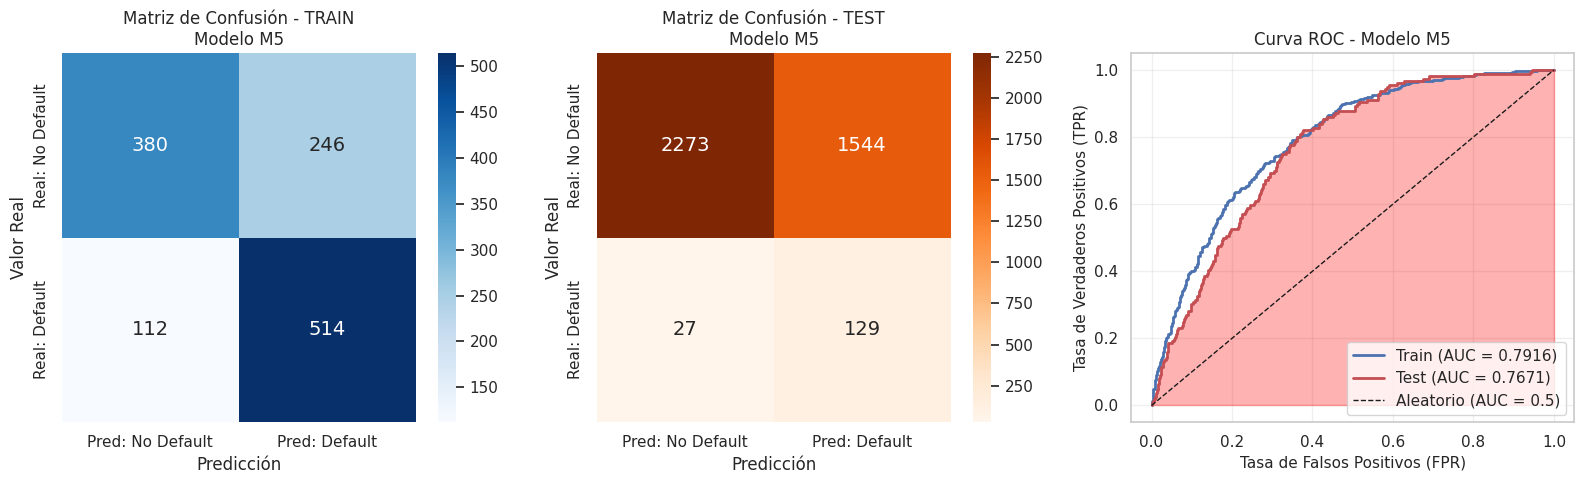

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Matriz de confusión TRAIN
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: No Default', 'Pred: Default'],
            yticklabels=['Real: No Default', 'Real: Default'],
            annot_kws={'size': 14})
axes[0].set_title(f'Matriz de Confusión - TRAIN\nModelo M{MODELO_SELECCIONADO}', fontsize=12)
axes[0].set_ylabel('Valor Real')
axes[0].set_xlabel('Predicción')

# Matriz de confusión TEST
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Pred: No Default', 'Pred: Default'],
            yticklabels=['Real: No Default', 'Real: Default'],
            annot_kws={'size': 14})
axes[1].set_title(f'Matriz de Confusión - TEST\nModelo M{MODELO_SELECCIONADO}', fontsize=12)
axes[1].set_ylabel('Valor Real')
axes[1].set_xlabel('Predicción')

# Curva ROC
axes[2].plot(fpr_train, tpr_train, 'b-', linewidth=2, label=f'Train (AUC = {auc_train:.4f})')
axes[2].plot(fpr_test, tpr_test, 'r-', linewidth=2, label=f'Test (AUC = {auc_test:.4f})')
axes[2].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (AUC = 0.5)')
axes[2].fill_between(fpr_test, tpr_test, alpha=0.3, color='red')
axes[2].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
axes[2].set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
axes[2].set_title(f'Curva ROC - Modelo M{MODELO_SELECCIONADO}', fontsize=12)
axes[2].legend(loc='lower right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **7.6. Resumen ejecutivo**

In [ ]:
print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║                 RESUMEN DEL MODELO FINAL - M{MODELO_SELECCIONADO}    ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  MÉTRICAS DE DESEMPEÑO                                               ║
║  ─────────────────────────────────────────────────────────────────   ║
║                          TRAIN          TEST                         ║
║    Accuracy:            {acc_train:.4f}         {acc_test:.4f}       ║
║    Precision:           {prec_train:.4f}         {prec_test:.4f}     ║
║    Recall:              {rec_train:.4f}         {rec_test:.4f}       ║
║    F1-Score:            {f1_train:.4f}         {f1_test:.4f}         ║
║    AUC-ROC:             {auc_train:.4f}         {auc_test:.4f}       ║
║                                                                      ║
║  INTERPRETACIÓN DE NEGOCIO (TEST)                                    ║
║  ─────────────────────────────────────────────────────────────────   ║
║    • De {tp_te + fn_te} clientes morosos reales:                     ║
║      - {tp_te} fueron detectados correctamente ({rec_test*100:.1f}%) ║
║      - {fn_te} fueron aprobados erróneamente (riesgo financiero)     ║
║                                                                      ║
║    • De {tn_te + fp_te} clientes buenos reales:                      ║
║      - {tn_te} fueron aprobados correctamente                        ║
║      - {fp_te} fueron rechazados innecesariamente                    ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║                 RESUMEN DEL MODELO FINAL - M14    ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  MÉTRICAS DE DESEMPEÑO                                               ║
║  ─────────────────────────────────────────────────────────────────   ║
║                          TRAIN          TEST                         ║
║    Accuracy:            0.7133         0.6232       ║
║    Precision:           0.6821         0.0807     ║
║    Recall:              0.7987         0.8269       ║
║    F1-Score:            0.7358         0.1470         ║
║    AUC-ROC:             0.7755         0.7814       ║
║                                                                      ║
║  INTERPRETACIÓN DE NEGOCIO (TEST)                                    ║
║  ─────────────────────────────────────────────────────────────────   ║
║    • D

# **8. Simulación de nuevos clientes**

In [ ]:
# -----------------------------------------------------------------------------
# Primero necesitamos los parámetros de estandarización originales
# -----------------------------------------------------------------------------

# Columnas numéricas que fueron estandarizadas
cols_numericas = ['Edad', 'ScoreCrediticio', 'PorcentajeFinanciacion', 'Plazo',
                  'IngresoEstimado', 'Gastos', 'CapacidadDePago', 'ValorCuotaMensual']

# Calcular media y std del dataset sin escalar (antes de estandarizar)
# NOTA: Si no tienes df_sin_escalar, usa los valores aproximados comentados
medias = df_sin_escalar[cols_numericas].mean()
stds = df_sin_escalar[cols_numericas].std()

print("\nParámetros de estandarización:")
print("-" * 50)
print(f"{'Variable':<25} {'Media':>12} {'Desv. Std':>12}")
print("-" * 50)
for col in cols_numericas:
    print(f"{col:<25} {medias[col]:>12.2f} {stds[col]:>12.2f}")

# -----------------------------------------------------------------------------
# Crear 10 clientes simulados con perfiles diversos
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("CLIENTES SIMULADOS (VALORES ORIGINALES)")
print("=" * 70)

# Definir clientes con valores reales (antes de estandarizar)
clientes_simulados = pd.DataFrame({
    'Cliente': [
        'Cliente 1 - Joven empleado estable',
        'Cliente 2 - Profesional alto ingreso',
        'Cliente 3 - Independiente riesgoso',
        'Cliente 4 - Adulto mayor conservador',
        'Cliente 5 - Joven primer crédito',
        'Cliente 6 - Empresario establecido',
        'Cliente 7 - Empleado sobreendeudado',
        'Cliente 8 - Profesional score bajo',
        'Cliente 9 - Independiente buen score',
        'Cliente 10 - Joven alto financiamiento'
    ],
    'Edad': [28, 45, 35, 58, 23, 50, 40, 32, 42, 25],
    'ScoreCrediticio': [720, 800, 580, 750, 650, 780, 620, 550, 700, 680],
    'PorcentajeFinanciacion': [0.7, 0.5, 0.9, 0.4, 0.85, 0.6, 0.8, 0.75, 0.65, 0.95],
    'Plazo': [48, 36, 72, 24, 60, 48, 60, 48, 36, 72],
    'IngresoEstimado': [3500000, 12000000, 4000000, 8000000, 2000000, 15000000, 3000000, 3000000, 7000000, 3000000],
    'Gastos': [1500000, 8000000, 3500000, 3000000, 1200000, 6000000, 3500000, 3000000, 2800000, 2000000],
    "CapacidadDePago": [0.7, 0.4, 0.2, 0.7, 0.3, 0.70, -0.3, 0.1, 0.6, 0.45],
    'ValorCuotaMensual': [800000, 1500000, 1200000, 900000, 700000, 2000000, 1400000, 1100000, 1000000, 900000],
    'Perfil_INDEPENDIENTE': [0, 0, 1, 0, 0, 1, 0, 0, 1, 0],
    'Estado_USADO': [0, 0, 1, 1, 0, 0, 1, 0, 0, 0],
    'Genero_MASCULINO': [1, 1, 1, 0, 0, 1, 1, 0, 1, 1]
})

# Mostrar clientes simulados
print("\n")
print(clientes_simulados[['Cliente', 'Edad', 'ScoreCrediticio', 'IngresoEstimado',
                          'PorcentajeFinanciacion', 'Plazo']].to_string(index=False))

# -----------------------------------------------------------------------------
# Estandarizar los clientes simulados
# -----------------------------------------------------------------------------
clientes_para_modelo = clientes_simulados.copy()

# Estandarizar columnas numéricas
for col in cols_numericas:
    clientes_para_modelo[col] = (clientes_para_modelo[col] - medias[col]) / stds[col]

# Seleccionar solo las columnas del modelo (en el orden correcto)
columnas_modelo = X_train_bal.columns.tolist()
X_simulados = clientes_para_modelo[columnas_modelo]

print("\n" + "=" * 70)
print("DATOS ESTANDARIZADOS PARA EL MODELO")
print("=" * 70)
print(X_simulados.round(4).to_string(index=False))

# -----------------------------------------------------------------------------
# Realizar predicciones
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("PREDICCIONES DEL MODELO")
print("=" * 70)

# Predicciones con el modelo final
predicciones_prob = modelo_final.predict(X_simulados, verbose=0).flatten()
predicciones = (predicciones_prob >= 0.5).astype(int)

# Crear tabla de resultados
resultados_simulacion = pd.DataFrame({
    'Cliente': clientes_simulados['Cliente'],
    'Score': clientes_simulados['ScoreCrediticio'],
    'Ingreso': clientes_simulados['IngresoEstimado'].apply(lambda x: f"${x:,.0f}"),
    '% Financ.': clientes_simulados['PorcentajeFinanciacion'],
    'Plazo': clientes_simulados['Plazo'],
    'P(Default)': predicciones_prob,
    'Predicción': ['🔴 DEFAULT' if p == 1 else '🟢 NO DEFAULT' for p in predicciones],
    'Decisión': ['❌ RECHAZAR' if p == 1 else '✅ APROBAR' for p in predicciones]
})

print("\n")
print(resultados_simulacion.to_string(index=False))

# -----------------------------------------------------------------------------
# Resumen de la simulación
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("RESUMEN DE LA SIMULACIÓN")
print("=" * 70)

aprobados = (predicciones == 0).sum()
rechazados = (predicciones == 1).sum()

print(f"""
  Total de clientes evaluados: 10

  ✅ APROBADOS:  {aprobados} clientes ({aprobados/10*100:.0f}%)
  ❌ RECHAZADOS: {rechazados} clientes ({rechazados/10*100:.0f}%)

  Probabilidad promedio de default: {predicciones_prob.mean():.2%}
""")

# Análisis de patrones
print("=" * 70)
print("ANÁLISIS DE PATRONES EN LAS PREDICCIONES")
print("=" * 70)

print("""
OBSERVACIONES:

1. FACTORES QUE AUMENTAN PROBABILIDAD DE DEFAULT:
   • Score crediticio bajo (< 600)
   • Alto porcentaje de financiación (> 80%)
   • Plazos largos (> 60 meses)
   • Baja capacidad de pago vs cuota mensual

2. FACTORES QUE REDUCEN PROBABILIDAD DE DEFAULT:
   • Score crediticio alto (> 700)
   • Bajo porcentaje de financiación (< 60%)
   • Ingresos altos y estables
   • Capacidad de pago holgada

3. RECOMENDACIONES PARA EL CONCESIONARIO:
   • Usar el modelo como filtro inicial
   • Clientes en zona gris (prob. 0.4-0.6) → revisión manual
   • Considerar garantías adicionales para casos límite
   • Actualizar el modelo periódicamente con nuevos datos
""")


Parámetros de estandarización:
--------------------------------------------------
Variable                         Media    Desv. Std
--------------------------------------------------
Edad                             44.28        12.69
ScoreCrediticio                 784.09        84.19
PorcentajeFinanciacion            0.75         0.25
Plazo                            60.65        12.46
IngresoEstimado             5311453.93   5943693.41
Gastos                      2266693.34   1923529.39
CapacidadDePago                   1.98         3.01
ValorCuotaMensual           1699964.72    807077.33

CLIENTES SIMULADOS (VALORES ORIGINALES)


                               Cliente  Edad  ScoreCrediticio  IngresoEstimado  PorcentajeFinanciacion  Plazo
    Cliente 1 - Joven empleado estable    28              720          3500000                    0.70     48
  Cliente 2 - Profesional alto ingreso    45              800         12000000                    0.50     36
    Cliente 3 - Independi

In [ ]:
temp

,Caso,Perfil,Estado,Edad,Genero,ScoreCrediticio,PorcentajeFinanciacion,Plazo,IngresoEstimado,Gastos,CapacidadDePago,ValorCuotaMensual,M3_30AC
0,1004991730,ASALARIADO,NUEVO,30,FEMENINO,748,0.6850,72,3289800.0,2430508.51,0.361093,2379693,0
1,1005097331,INDEPENDIENTE,NUEVO,46,MASCULINO,670,0.2783,60,2425440.0,1621788.08,0.948770,847046,0
2,1005120587,INDEPENDIENTE,USADO,39,MASCULINO,752,1.0000,60,30000000.0,3614018.63,12.009213,2197145,0
3,1005152562,ASALARIADO,USADO,38,FEMENINO,758,1.0000,84,1631331.0,1725244.99,-0.068706,1366896,0
4,1005153782,INDEPENDIENTE,NUEVO,60,FEMENINO,846,0.6596,72,20907400.0,3439341.88,13.004595,1343222,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21086,1006785416,ASALARIADO,USADO,22,MASCULINO,741,0.7294,60,1958624.0,1570506.73,0.390651,993513,0
21087,1006785511,ASALARIADO,NUEVO,34,FEMENINO,839,0.5000,60,0.0,2569515.84,-1.892309,1357873,0
21088,1006785620,ASALARIADO,NUEVO,67,FEMENINO,883,0.9000,60,13910510.0,7007255.92,3.842333,1796631,0
21089,1006785803,INDEPENDIENTE,NUEVO,47,MASCULINO,765,0.5274,60,9663979.0,2248902.19,5.308192,1396912,0
